# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFScar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>
  
<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final</center>

**Nome**:
1) Daniella Yuka Hirosue
2) Lara Oliveira Luzeiro
3) Renan Yugo Ueda

**RA**: 
1) 813008
2) 813259
3) 813346


In [1]:
import os
import shutil

# 1. Acha automaticamente o nome que o Kaggle deu para o seu upload
pastas_input = [d for d in os.listdir('/kaggle/input/') if not d.startswith('.')]
pasta_origem = f"/kaggle/input/{pastas_input[0]}"

# 2. Copia tudo para uma pasta com nome fixo e seguro
pasta_destino = "/kaggle/working/meu_projeto_local"
if not os.path.exists(pasta_destino):
    shutil.copytree(pasta_origem, pasta_destino, dirs_exist_ok=True)

# 3. Procura a subpasta exata onde estão os seus arquivos (dataset/scripts) e entra nela
for raiz, diretorios, arquivos in os.walk(pasta_destino):
    # Procura a pasta que contém a subpasta 'dataset' ou 'scripts'
    if 'dataset' in diretorios or 'scripts' in diretorios:
        os.chdir(raiz)
        print(f"SUCESSO! O Python agora está rodando de dentro da pasta: {os.getcwd()}")
        break

SUCESSO! O Python agora está rodando de dentro da pasta: /kaggle/working/meu_projeto_local/renanyugoueda/implementacao-final/PLN-Projeto


---
## Configuracao do Ambiente

Instala as dependencias necessarias para o projeto.  
Execute esta celula **uma unica vez** antes de prosseguir.

In [2]:
import subprocess, sys

if sys.version_info >= (3, 14):
    raise RuntimeError(
        "Este notebook precisa rodar em Python 3.11 para usar gensim/Word2Vec. "
        "No VS Code, clique no kernel do notebook e selecione: Python 3.11 (pln_teste)."
    )

pacotes = [
    "scikit-learn", "matplotlib", "seaborn", "ftfy",
    "nltk", "spacy", "gensim", "torch", "transformers",
    "datasets", "wordcloud", "scipy", "accelerate",
]

for pacote in pacotes:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pacote], check=False)

# Modelo de linguagem portugues do spaCy
subprocess.run([sys.executable, "-m", "spacy", "download", "pt_core_news_lg"], check=False)

# Recursos NLTK
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)
nltk.download("rslp",      quiet=True)

print("Ambiente configurado com sucesso.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Ambiente configurado com sucesso.


---
## Imports e Configuracao Global

In [3]:
import os
import sys
import warnings
import random
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Garante que a pasta scripts seja encontrada
sys.path.insert(0, os.path.abspath('.'))

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# Semente global para reproducibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Importa modulos do projeto
from scripts.analise_exploratoria import (
    MAPEAMENTO_CLASSES, 
    carregar_dados, exibir_info_geral, analisar_duplicados, problemas_codificacao,
    calcular_distribuicao_classes, plotar_distribuicao_classes,
    filtrar_rotulos_validos,
    calcular_estatisticas_tamanho_textos, calcular_estatisticas_tamanho_por_classe,
    plotar_comprimento_textos,
    calcular_palavras_frequentes_por_classe, converter_para_dict_frequencias,
    plotar_palavras_frequentes, plotar_nuvem_palavras,
    analisar_vocabulario, 
)
from scripts.preprocessamento import (
    carregar_modelo_spacy,
    extrair_texto_json, corrigir_encoding, normalizar_unicode,
    limpar_ruido_ocr, tokenizar_texto, remover_stopwords_tokens,
    lematizar_tokens, aplicar_pipeline,
    remover_documentos_duplicados, remover_textos_vazios,
    verificar_ruidos_dataset,
    aplicar_pos_tagging,
    extrair_entidades_nomeadas, extrair_mencoes_legais,
    extrair_features_linguisticas, plotar_distribuicao_pos,
)
from scripts.experimentos import (
    dividir_treino_validacao, vetorizar_tfidf,
    treinar_regressao_logistica, treinar_svm_linear, treinar_naive_bayes,
    avaliar_validacao_cruzada,
    treinar_word2vec, vetorizar_word2vec_media,
    aplicar_ner_juridico,
)
from scripts.analise_resultados import (
    comparar_modelos,
    plotar_comparacao_modelos,
    plotar_matriz_confusao,
    plotar_curvas_treinamento,
    teste_mcnemar,
    analisar_erros,
    registrar_resultado_modelo,
    selecionar_top_modelos,
    obter_probabilidades_bilstm,
    obter_probabilidades_legal_bert,
    combinar_probabilidades,
    predizer_por_probabilidades,
    gerar_submissao,
)

# ---- Flags de controle de execucao ----
EXECUTAR_BILSTM       = True     # False para pular o modelo profundo
EXECUTAR_TRANSFORMER  = True     # False para pular o fine-tuning BERT
USAR_TRANSFORMER_SUB  = True     # True = submissao final usa transformer

print("Modulos e configuracoes carregados com sucesso.")
print(f"  BiLSTM        : {EXECUTAR_BILSTM}")
print(f"  Transformer   : {EXECUTAR_TRANSFORMER}")

Modulos e configuracoes carregados com sucesso.
  BiLSTM        : True
  Transformer   : True


---
## 1. Análise Exploratória
A etapa de análise exploratória teve como objetivo compreender a estrutura do conjunto de dados, tanto da perspectiva quantitativa, quanto linguística, além de identificar possíveis problemas de qualidade e extrair informações relevantes que auxiliem na etapa de pré-processamento. O conjunto de dados disponibilizado é composto por documentos jurídicos rotulados em diferentes categorias. Cada instância representa um documento associado a uma classe que será utilizada como variável alvo no problema de classificação. Para atingir esses objetivos, o processo da análise incluiu diversas etapas que juntas avaliaram: consistência, qualidade e distribuição dos dados, estatísticas de comprimento e padronização e distribuição linguística. 

### 1.1. Carregamento de dados

In [4]:
df_treino, df_teste = carregar_dados('dataset/train.csv', 'dataset/test.csv')

### 1.2. Significado dos Atributos

* `Id(Identificador)`: Um número inteiro único e sequencial atribuído a cada documento do conjunto de dados para auxiliar na rastreabilidade. 

* `Body (Corpo do Texto)`: Texto bruto extraído das páginas em PDF dos processos judiciais do STF. 

* `Category (Categoria / Rótulo)`: Rótulo numérico que identifica qual é o tipo daquele documento. 
    * 0 = Acordão
    * 1 = ARE (Agravo de Recurso Extraordinário)
    * 2 = Despacho 
    * 3 = RE (Recurso Extraordinário)
    * 4 = Sentença

> **Observação**: a base de treino contem amostras com `Category = -1` (sem rótulo).

### 1.3. Visão Geral dos Dados

Esta seção tem como objetivo fornecer uma visão inicial do conjunto de dados. Foram analisadas características básicas, como quantidade de amostras, presença de valores ausentes, documentos duplicados e possíveis problemas de codificação textual. Essas informações permitem avaliar a qualidade dos dados e identificar possíveis etapas de pré-processamento necessárias. 

In [5]:
exibir_info_geral(df_treino, df_teste)

df_treino_analise = df_treino.copy()

print(f"\nFormato treino  : {df_treino.shape}")
print(f"Formato teste   : {df_teste.shape}")
display(df_treino_analise.head(3))

analisar_duplicados(df_treino_analise)
problemas_codificacao(df_treino_analise)

VISAO GERAL DOS DADOS

Treino : 22,680 amostras | 3 colunas
Teste  :  2,521 amostras | 2 colunas

Colunas treino: ['Id', 'Body', 'Category']
Colunas teste : ['Id', 'Body']

Valores ausentes (treino):
Id          0
Body        0
Category    0

Amostras sem rotulo (Category == -1) : 2,268
Amostras rotuladas  (Category >= 0)  : 20,412

Formato treino  : (22680, 3)
Formato teste   : (2521, 2)


,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fu...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o disc...",1



DOCUMENTOS DUPLICADOS
Quantidade de duplicados :   11,183
Percentual do dataset    : 49.31%

PROBLEMAS DE CODIFICACAO
Documentos afetados :   22,644
Percentual do dataset: 99.84%


### 1.4. Distribuição das Classes

Esta seção tem como objetivo analisar como os documentos estão divididos entre as diferentes categorias. Foram examinadas as contagens absolutas e as proporções de cada classe, bem como a presença de rótulos inválidos. Essa distribuição permite identificar o nível de desbalanceamento do dataset, o que impacta diretamente a escolha de estratégias de modelagem e de métricas de avaliação.

Distribuicao de Classes (treino):


,classe,quantidade,percentual,nome_classe
0,-1,2268,10.000000,Rotulo invalido
1,0,665,2.932099,Acordao
2,1,3529,15.559965,ARE
3,2,439,1.935626,Despacho
4,3,12876,56.772487,RE
5,4,2903,12.799824,Sentenca


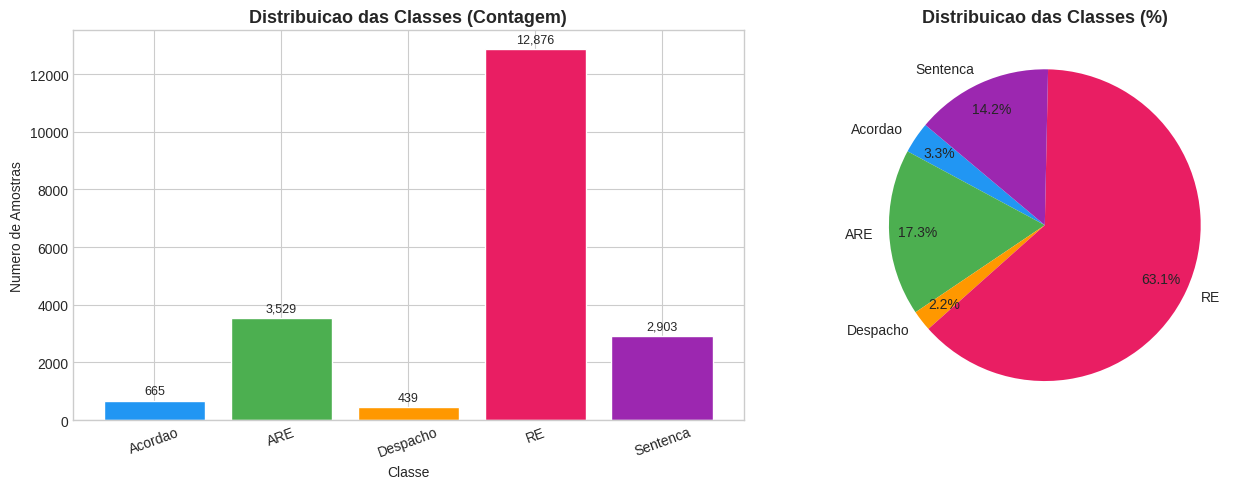

In [6]:
distribuicao = calcular_distribuicao_classes(df_treino_analise, incluir_rotulos_invalidos=True)
print("Distribuicao de Classes (treino):")
display(distribuicao)
plotar_distribuicao_classes(distribuicao)

### 1.5. Comprimento dos Textos

Esta seção tem como objetivo analisar a extensão dos documentos textuais presentes no conjunto de dados. Foram calculadas estatísticas descritivas referentes à quantidade de tokens (palavras) tanto no escopo global quanto divididas por categoria, incluindo métricas como média, mediana, desvio padrão e valores extremos. Desse modo será possível identificar outliers, como documentos quase vazios ou muito longos, e auxiliar nas decisões de pré-processamento.

Estatisticas Gerais de Comprimento:


,quantidade_documentos,media_tokens,mediana_tokens,desvio_padrao_tokens,minimo_tokens,maximo_tokens,percentil_90_tokens,percentil_95_tokens
0,20412,216.245934,209.0,92.824114,0,844,327.0,380.0



Estatisticas por Classe (tokens):


,Category,quantidade_documentos,media_tokens,mediana_tokens,desvio_padrao_tokens,minimo_tokens,maximo_tokens,nome_classe
0,0,665,251.539850,262.0,114.338256,19,576,Acordao
1,1,3529,195.198923,181.0,90.093587,0,685,ARE
2,2,439,149.036446,152.0,102.660404,14,844,Despacho
3,3,12876,213.882883,206.0,87.938303,4,781,RE
4,4,2903,254.391319,243.0,94.121400,13,837,Sentenca


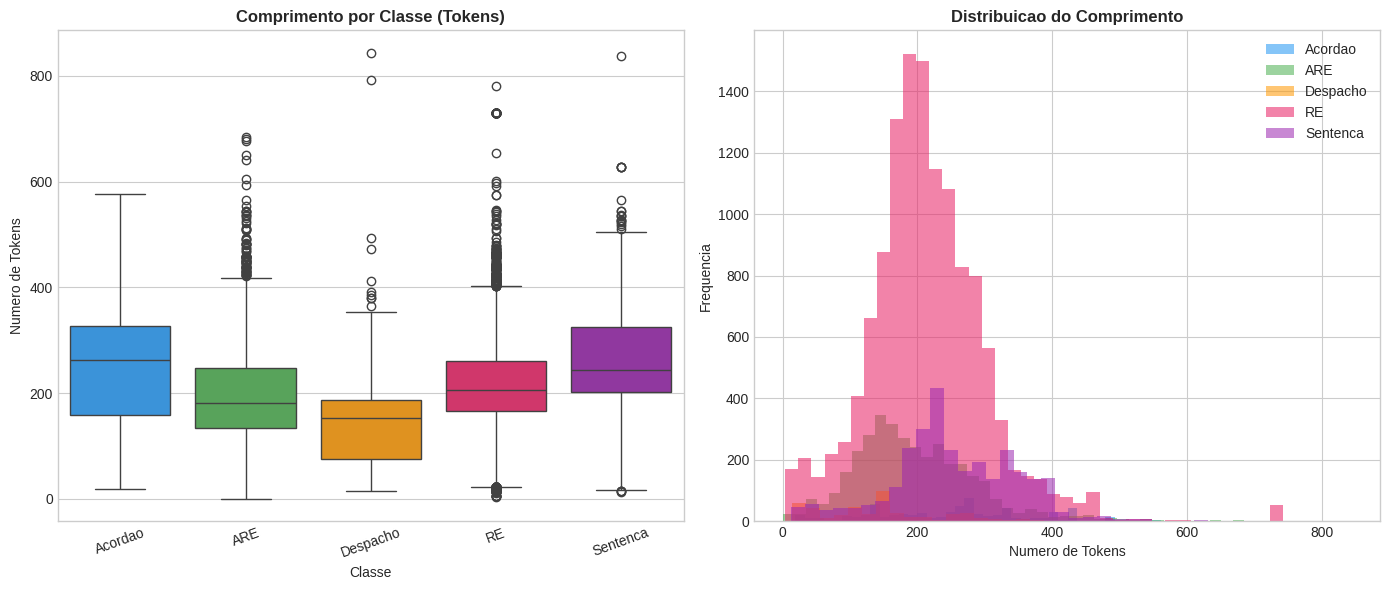

In [7]:
df_validos = filtrar_rotulos_validos(df_treino_analise)

stats_gerais = calcular_estatisticas_tamanho_textos(df_validos)
print("Estatisticas Gerais de Comprimento:")
display(stats_gerais)

stats_por_classe = calcular_estatisticas_tamanho_por_classe(df_validos)
print("\nEstatisticas por Classe (tokens):")
display(stats_por_classe)

plotar_comprimento_textos(df_validos)

### 1.6. Palavras Mais Frequentes e Nuvem de Palavras

Esta seção tem como objetivo explorar o vocabulário no conjunto de dados e destacar os termos mais frequentes de cada categoria. Além disso, foram geradas representações visuais, como gráficos de barras e nuvens de palavras. 


CLASSE 0: ACORDAO


,classe,nome_classe,palavra,frequencia
0,0,Acordao,recurso,1041
1,0,Acordao,federal,1041
2,0,Acordao,parte,938
3,0,Acordao,turma,854
4,0,Acordao,valor,813
5,0,Acordao,relator,652
6,0,Acordao,pagamento,627
7,0,Acordao,julgamento,621
8,0,Acordao,autos,603
9,0,Acordao,juiz,589



CLASSE 1: ARE


,classe,nome_classe,palavra,frequencia
20,1,ARE,recurso,7294
21,1,ARE,federal,4951
22,1,ARE,geral,2907
23,1,ARE,agravo,2834
24,1,ARE,direito,2790
25,1,ARE,tribunal,2631
26,1,ARE,constitucional,2605
27,1,ARE,presente,2235
28,1,ARE,turma,2141
29,1,ARE,especial,2025



CLASSE 2: DESPACHO


,classe,nome_classe,palavra,frequencia
40,2,Despacho,recurso,1426
41,2,Despacho,agravo,917
42,2,Despacho,federal,743
43,2,Despacho,recursal,677
44,2,Despacho,turma,654
45,2,Despacho,tribunal,568
46,2,Despacho,autos,427
47,2,Despacho,desta,425
48,2,Despacho,processo,395
49,2,Despacho,interposto,385



CLASSE 3: RE


,classe,nome_classe,palavra,frequencia
60,3,RE,federal,19590
61,3,RE,geral,16238
62,3,RE,fazenda,16032
63,3,RE,procuradoria,14611
64,3,RE,nacional,14147
65,3,RE,recurso,13734
66,3,RE,direito,11312
67,3,RE,constitucional,11182
68,3,RE,servidores,8716
69,3,RE,tribunal,8417



CLASSE 4: SENTENCA


,classe,nome_classe,palavra,frequencia
80,4,Sentenca,federal,4042
81,4,Sentenca,servidores,3568
82,4,Sentenca,parte,3559
83,4,Sentenca,valor,3143
84,4,Sentenca,data,2643
85,4,Sentenca,desempenho,2498
86,4,Sentenca,gdpst,2422
87,4,Sentenca,partir,2405
88,4,Sentenca,rel,2258
89,4,Sentenca,direito,2196


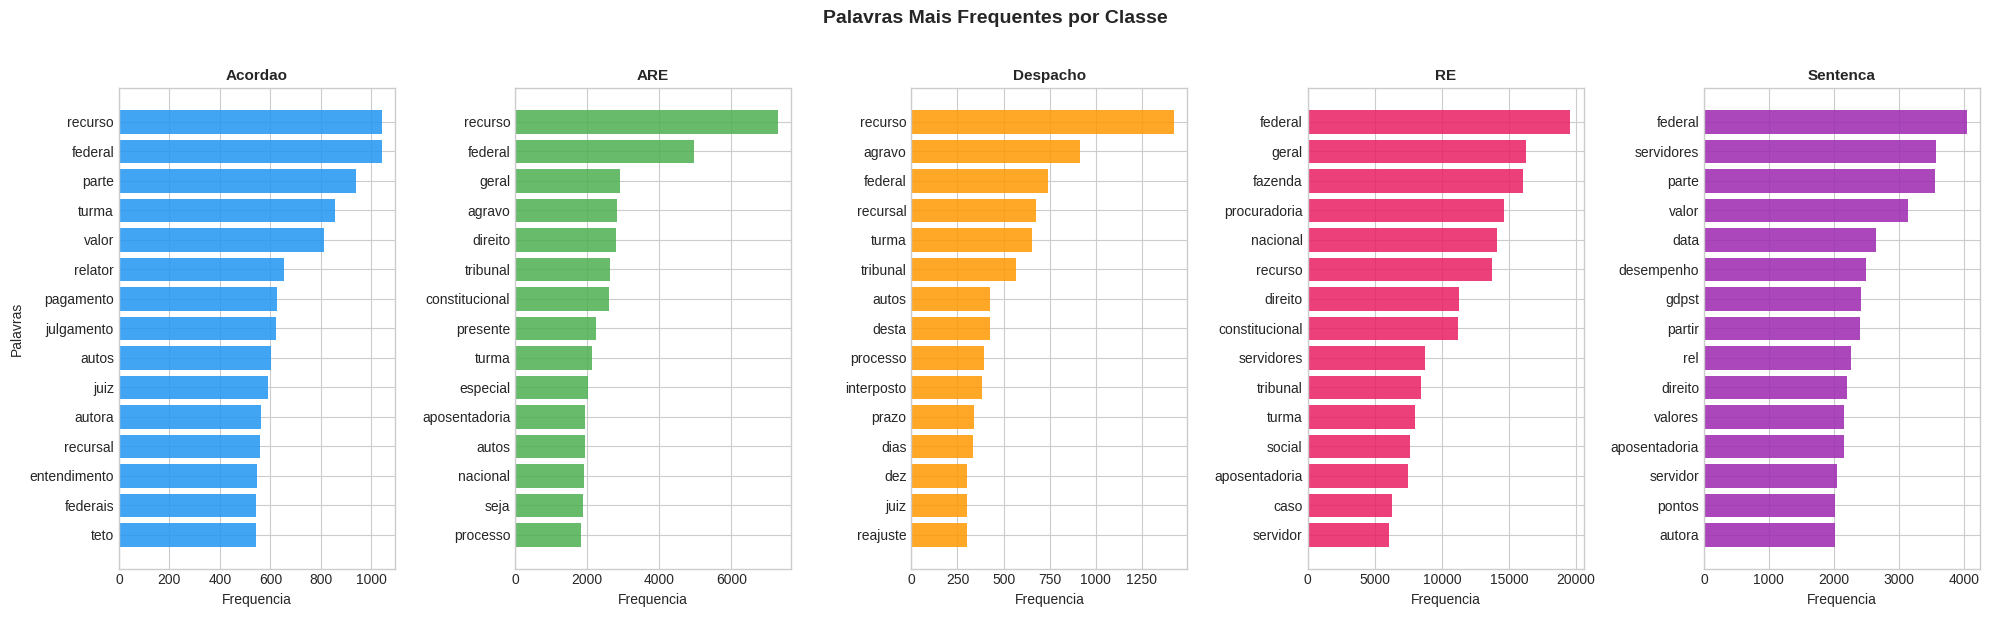

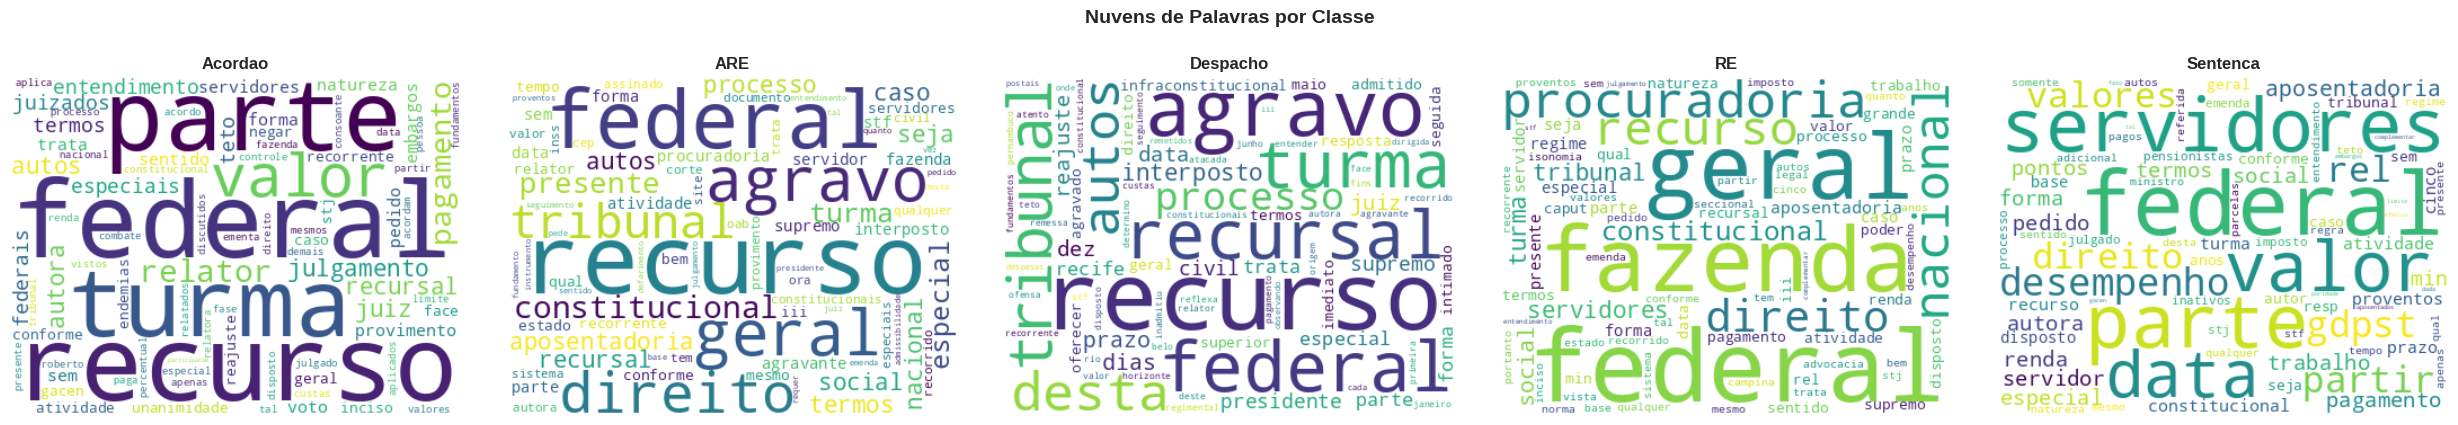

In [8]:
df_freq = calcular_palavras_frequentes_por_classe(df_validos, top_n=20)
for classe_id, grupo in df_freq.groupby('classe'):
    nome_classe = grupo['nome_classe'].iloc[0]
    print(f"\n{'='*40}")
    print(f"CLASSE {classe_id}: {nome_classe.upper()}")
    print(f"{'='*40}")
    display(grupo)

freq_dict = converter_para_dict_frequencias(df_freq, n_palavras=15)
plotar_palavras_frequentes(freq_dict, n_palavras=15)

plotar_nuvem_palavras(df_validos)

In [9]:
vocab_global = analisar_vocabulario(df_validos)


Analise de Vocabulario (corpus rotulado):
  Tipos unicos (vocab total) :   30,441
  Total de tokens            : 2,563,900
  Tokens com freq >= 5       :   12,661
  Tokens com freq >= 10      :    9,424

Top 20 palavras mais frequentes (geral):
  federal                          30,367
  recurso                          24,945
  geral                            21,051
  fazenda                          18,265
  nacional                         17,139
  direito                          16,835
  procuradoria                     16,246
  constitucional                   15,792
  servidores                       13,820
  tribunal                         13,265
  turma                            13,177
  aposentadoria                    11,762
  parte                            11,406
  social                           11,341
  especial                          9,717
  forma                             9,716
  caso                              9,678
  seja                              9,54

### 1.7. Constatações

1) **Distribuição das categorias**<br>
O conjunto de treinamento é fortemente desbalanceado. A classe RE representa a maioria do *dataset* (aproximadamente 57% das amostras), enquanto as classes Acordão (cerca de 3%) e Despacho (menos de 2%) são consideradas categorias raras. Também verificou-se que 10% do conjunto de dados (2.268 amostras) consistem em rótulos inválidos (-1).<br>
<u><b>Conclusão</b></u>: Foi identificada a necessidade de realizar a limpeza das amostras sem rótulo. Devido à assimetria dos dados, será necessário o uso de técnicas para diminuir o desbalanceamento, como a aplicação de pesos de classe, além da adoção da métrica **F1-Macro** como principal critério de avaliação dos modelos.

2) **Grande variabilidade no tamanho dos documentos em geral**<br>
As estatísticas descritivas e os gráficos de distribuição (histogramas e *boxplots*) evidenciaram uma variação extrema na extensão dos textos. O *dataset* abrange documentos quase vazios (mínimo de 1 *token*) até textos massivos (máximo de 8.443 *tokens*). Apesar da média geral estar em torno de 216 palavras, a presença de uma grande quantidade de *outliers* aumenta a cauda da distribuição.<br>
<u><b>Conclusão</b></u>: A alta amplitude mostra a importância da definição de um limite de truncamento (`max_len`) para preservar a informação na maioria dos documentos e otimizar o desempenho de algoritmos sequenciais (como BiLSTM e BERT).

3) **Diferenças de tamanho entre categorias**<br>
A quebra do comprimento por classe revelou alguns comportamentos estruturais. Documentos da categoria Despacho tendem a ser consideravelmente mais curtos (mediana de 152 palavras), enquanto Acordãos e Sentenças apresentam textos mais longos (médias ultrapassando 250 palavras).<br>
<u><b>Conclusão</b></u>: O tamanho do documento possui alto poder discriminativo. Essa variável pode ser extraída como uma *feature* auxiliar para os modelos clássicos. Além disso, o limite de truncamento textual precisa levar em conta a estrutura mais extensa de Acordãos e Sentenças.

4) **Vocabulário amplo e especializado**<br>
A análise lexical confirmou um vocabulário primário superior a 30 mil tipos únicos, inseridos num total de mais de 2,5 milhões de *tokens*. Observou-se o domínio do jargão do meio jurídico ("federal", "recurso", "geral", "fazenda", "procuradoria").<br>
<u><b>Conclusão</b></u>: Métodos de representação textual que consigam priorizar a relevância de termos dentro do domínio (como TF-IDF) ou capturar o contexto da linguagem jurídica tendem a superar abordagens baseadas apenas em contagem simples.

5) **Existência de vocabulário característico por categoria**<br>
As frequências e nuvens de palavras mostraram dois cenários diferentes. As classes de ARE e RE possuem grande sobreposição semântica, dividindo os mesmos termos mais frequentes. Em contrapartida, Despacho tem um vocabulário específico relacionado ao tempo ("prazo", "dias", "dez") e Sentença reflete uma presença de termos relacionados a pagamentos ("gdpst", "pagamento", "valores").<br>
<u><b>Conclusão</b></u>: Pode-se identificar uma separação de temas em categorias como Despacho e Sentença. Porém, a alta semelhança de vocabulários entre ARE e RE mostra uma possível zona de confusão dos algoritmos preditivos na distinção entre essas categorias.

6) **Problemas de codificação textual**<br>
Foi identificada a ocorrência de caracteres incorretamente codificados em diversos documentos, produzindo expressões como: "constituiÃ§Ã£o", "decisÃ£o". Esse problema, presente em 99,84% dos documentos (22.644 amostras), aumenta o tamanho do vocabulário e introduz ruídos nas representações textuais.<br>
<u><b>Conclusão</b></u>: Será aplicada uma correção de codificação para reduzir ruídos e melhorar a qualidade das representações linguísticas.

7) **Documentos duplicados**<br>
Observou-se uma alta taxa de documentos repetidos: 11.183 documentos duplicados, representando quase metade (49,31%) de todo o conjunto de treinamento.<br>
<u><b>Conclusão</b></u>: Será aplicada uma etapa de remoção de duplicatas para evitar superajuste (*overfitting*) sobre padrões repetitivos e melhorar a capacidade de generalização em novos textos.

---
## 2. Pre-processamento

A etapa de pré-processamento tem como objetivo transformar os dados textuais brutos em uma representação estruturada, limpa e adequada para o treinamento dos modelos, que será realizado na etapa seguinte. Utilizando as conclusões constatadas na etapa anterior de Análise Exploratória, esta fase atua diminuindo os ruídos identificados e destacando as características mais discriminativas do corpus, garantindo que os algoritmos foquem nos padrões linguísticos relevantes. Para tanto, foram aplicados os seguintes processos: higienização, padronização, truncamento, tratamento linguístico e engenharia de atributos. 
Ao final desta etapa, o esperado é que o conjunto de dados tenha apenas atributos consistentes e que maximizem a capacidade preditiva dos algoritmos. 

### 2.1. Carregamento do modelo spaCy

In [10]:
try:
    nlp = carregar_modelo_spacy('pt_core_news_lg')
    print(f"Modelo spaCy carregado: pt_core_news_lg")
except OSError:
    print("Modelo pt_core_news_lg nao encontrado.")
    nlp = None

Modelo spaCy carregado: pt_core_news_lg


### 2.2. Demonstração das etapas de limpeza

Foi isolada uma amostra do texto bruto para ilustrar cada transformação aplicada no processo de higienização, são elas:
 * Extração estrutural (extrair_texto_json): remoção de caracteres de formatação, mantendo apenas o conteúdo textual de interesse.
 * Restauração de Codificação (corrigir_encoding e normalizar_unicode): padronização de caracteres e correção de erros de grafia oriundos de termos corrompidos da base original.
 * Limpeza e Tokenização (limpar_ruido_ocr e tokenizar_texto): conversão do texto em uma lista de tokens, padronizadas em letras minúsculas e livres de pontuações.
 * Filtragem de Semântica (remover_stopwords_tokens): eliminação de termos funcionalmente vazios.
 * Redução Morfológica (lematizar_tokens): uso do spaCy para reduzir os termos à sua raizo, importante para unificar o vocabulário, especialmente variações como plurais e conjugações verbais.

In [11]:
exemplo_bruto = df_treino['Body'].iloc[0]
print("=== TEXTO BRUTO (primeiros 300 chars) ===")
print(exemplo_bruto[:300])
print()

# Extração do texto JSON e aplicação de etapas de limpeza e correção
t1 = extrair_texto_json(exemplo_bruto)
print("=== APOS extrair_texto_json ===")
print(t1[:300])
print()

# Demais limpezas
t2 = corrigir_encoding(t1)
t3 = normalizar_unicode(t2)
t4 = limpar_ruido_ocr(t3)
tokens = tokenizar_texto(t4, converter_minusculas=True)

# Remoção de stopwords
tokens_sem_sw = remover_stopwords_tokens(tokens)

print("=== TOKENS APOS remocao de stopwords (primeiros 30) ===")
print(tokens_sem_sw[:30])

# Lematização
if nlp is not None:
    tokens_lem = lematizar_tokens(tokens_sem_sw, nlp=nlp)
    tokens_lem = remover_stopwords_tokens(tokens_lem)
    print("\n=== TOKENS APOS LEMATIZACAO (primeiros 30) ===")
    print(tokens_lem[:30])

=== TEXTO BRUTO (primeiros 300 chars) ===
{"conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido conhecido provido fim que seja anulado v acÃ³rdÃ£o impugnado assim nÃ£o entender que seja inteiramente reformado por violaÃ§Ã£o flagrante aos disp

=== APOS extrair_texto_json ===
conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido conhecido provido fim que seja anulado v acÃ³rdÃ£o impugnado assim nÃ£o entender que seja inteiramente reformado por violaÃ§Ã£o flagrante aos dispos

=== TOKENS APOS remocao de stopwords (primeiros 30) ===
['conclusão', 'diante', 'exposto', 'recorrente', 'espera', 'confia', 'recurso', 'ora', 'arrazoado', 'interposto', 'fulcro', 'artigo102', 'iii', 'constituição', 'federal', 'admitido', 'conhecido', 'provido', 'fim', 'anulado', 'acórdão', 'impugnado', 'assim', 'entende

### 2.3. Aplicação de limpeza no dataset inteiro

Após a visualização das etapas individuais de higienização, esta seção aplica as etapas de limpeza citadas anteriormente a toda a base de dados (conjuntos de treinamento e teste). Nesta etapa foram excluídas as amostras não rotuladas (Category == -1) e os documentos duplicados com base no texto bruto (Body). Depois dessas exclusões e da aplicação das etapas mencionadas na seção anterior, foram descartados documentos que se tornaram vazios, ou seja, que possuíam zero tokens válidos devido à remoção de ruídos e stopwords. Ao final da execução, o corpus é consolidado em uma versão limpa e estruturada, estabelecendo a base que será utilizada nas etapas seguintes. 

In [12]:
# Remoção de rótulos inválidos
df_treino_valido = df_treino[df_treino['Category'] >= 0].copy()
print(f"Removidos {len(df_treino) - len(df_treino_valido):,} rótulos inválidos (-1).")

# Remoção de duplicatas
df_treino_valido2 = remover_documentos_duplicados(df_treino_valido, coluna='Body')
print(f"Removidos {len(df_treino_valido) - len(df_treino_valido2):,} documentos duplicados.")

# Preprocessa o treino 
df_treino_proc = aplicar_pipeline(
    df_treino_valido2, coluna='Body',
    nlp=nlp,
    lematizar=True,
    verbose=True,
)

# Remoção de textos que zeraram a quantidade de tokens após as limpezas
df_rot = remover_textos_vazios(df_treino_proc, coluna='texto_preprocessado').reset_index(drop=True)
print(f"Removidos {len(df_treino_proc) - len(df_rot):,} documentos vazios.")

# Remoção de duplicatas novamente, pois documentos podem ter se tornado iguais após limpezas
df_rot = df_rot.drop_duplicates(subset=['texto_preprocessado']).reset_index(drop=True)

print(f"\nAmostras limpas disponíveis para treinamento: {len(df_rot):,}")

# Preprocessa conjunto de teste
df_teste_proc = aplicar_pipeline(
    df_teste, coluna='Body',
    nlp=nlp,
    lematizar=True,
    verbose=True,
)

display(df_rot[['Body', 'texto_preprocessado', 'Category']].head(3))

Removidos 2,268 rótulos inválidos (-1).
Removidos 9,843 documentos duplicados.
Preprocessando 10,569 textos (com lematizacao (spaCy))...
   2,000 / 10,569 processados
   4,000 / 10,569 processados
   6,000 / 10,569 processados
   8,000 / 10,569 processados
  10,000 / 10,569 processados
Preprocessamento concluido.
Removidos 1 documentos vazios.

Amostras limpas disponíveis para treinamento: 10,540
Preprocessando 2,521 textos (com lematizacao (spaCy))...
   2,000 / 2,521 processados
Preprocessamento concluido.


,Body,texto_preprocessado,Category
0,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fu...",conclusão diante exposto recorrente esperar confiar recurso ora arrazoar interposto fulcro artig...,3
1,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ...",artigo55 gecen gacen devir titular emprego cargo público tratar artigo53 de este lei caráter per...,3
2,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o disc...",seguir desacerto decisão negar seguimento recurso extraordinário equívoco decisão discutir const...,1


### 2.4. Verificação de ruídos

Após a aplicação de etapas da limpeza, os documentos, agora filtrados, foram verificados novamente para atestar que agora estão livres de ruídos e demais problemas. 

In [13]:
verificar_ruidos_dataset(df_rot, coluna_texto='texto_preprocessado', coluna_alvo='Category')

=== VERIFICAÇÃO DE RUÍDOS NO DATASET PÓS-PROCESSAMENTO ===

1. Documentos nulos (NaN): 0
2. Documentos totalmente vazios (''): 0
3. Rótulos inválidos (Category < 0): 0
4. Duplicatas no texto processado: 0

5. Estatísticas de comprimento (tokens):
   - Mínimo de tokens em um documento: 3
   - Máximo de tokens em um documento: 687
   - Documentos com menos de 3 tokens úteis: 0

Dataset limpo e estruturado.


### 2.5. Demonstração de POS Tagging, NER e Análise por Classe
Nesta seção são extraídas características linguísticas para enriquecer a representação matemática dos documentos, são elas:
 * **POS Tagging (Anotação Morfossintática)**: classifica a categoria gramatical de cada termo. Como textos jurídicos possuem alta quantidade de substantivos (NOUN) e nomes próprios (PROPN), entender a proporção dessas classes permite que o modelo capture a estrutura de cada tipo de documento.
 * **NER (Reconhecimento de Entidades) e Referências**: foi adotado o modelo `pt_core_news_lg` do spaCy para português. Diferentemente do `pt_core_news_sm`, essa versão possui maior cobertura lexical e apresenta melhor desempenho na análise linguística, lematização, POS Tagging e reconhecimento de entidades nomeadas. Essa extração é combinada com o uso de expressões regulares (regex) para capturar referências a leis e dispositivos legais.


In [14]:
if nlp is not None:
    # POS tagging: exemplo 
    print("=== POS Tagging (exemplo) ===")
    exemplo_proc = df_rot['texto_preprocessado'].iloc[0]
    pares_pos = aplicar_pos_tagging(exemplo_proc[:500], nlp=nlp)
    for token, pos, tag in pares_pos[:20]:
        print(f"  {token:<20} {pos:<8} {tag}")

    # NER: exemplo 
    print("\n=== NER (exemplo) ===")
    entidades = extrair_entidades_nomeadas(exemplo_proc[:1000], nlp=nlp)
    for ent in entidades[:10]:
        print(f"  [{ent['tipo']}] {ent['texto']}")

    # Menções legais via regex: exemplo 
    print("\n=== Mencoes legais via regex (exemplo) ===")
    mencoes = extrair_mencoes_legais(exemplo_proc[:2000], nlp=nlp)
    display(pd.DataFrame([mencoes]))
else:
    print("spaCy nao disponivel.")

=== POS Tagging (exemplo) ===
  conclusão            NOUN     NOUN
  diante               ADV      ADV
  exposto              VERB     VERB
  recorrente           ADJ      ADJ
  esperar              VERB     VERB
  confiar              VERB     VERB
  recurso              NOUN     NOUN
  ora                  ADV      ADV
  arrazoar             VERB     VERB
  interposto           VERB     VERB
  fulcro               NOUN     NOUN
  artigo102            VERB     VERB
  iii                  PROPN    PROPN
  constituição         NOUN     NOUN
  federal              ADJ      ADJ
  admitir              VERB     VERB
  conhecer             VERB     VERB
  provir               VERB     VERB
  fim                  NOUN     NOUN
  anular               VERB     VERB

=== NER (exemplo) ===
  [PER] alexandre simões camara silva

=== Mencoes legais via regex (exemplo) ===


,entidades_spacy,mencoes_legais_regex
0,[alexandre simões camara silva],[artigo102]


### 2.6. Aplicação de POS Tagging, NER e Análise por Classe em amostra e no dataset inteiro


NER - top entidades em 800 amostras:
  PER       :  1946  | ex: alexandre simões camara silva, instituír, instituír
  ORG       :  1260  | ex: stf, stf, fazenda nacional
  LOC       :   846  | ex: artigo203, campina grande, mato grosso
  MISC      :   256  | ex: artigo1, artigo2, xyz zab


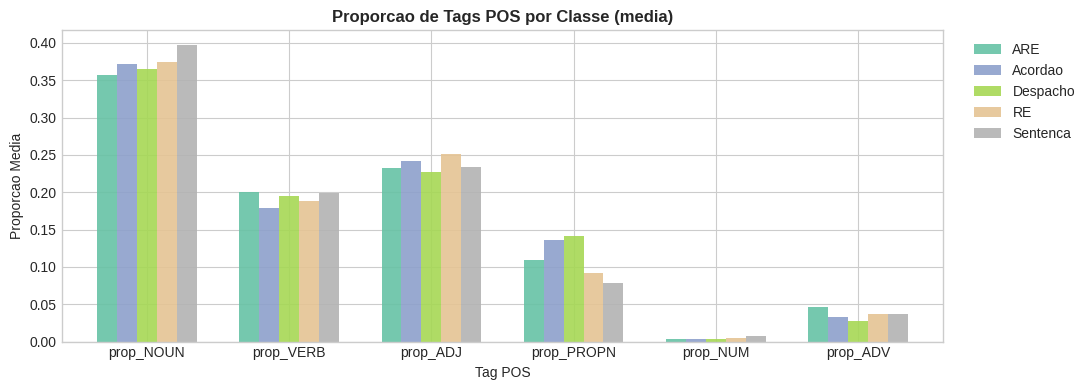

Formato final do DataFrame: (10540, 21)


In [15]:
if nlp is not None:
    # NER em amostra do corpus
    textos_amostra = df_rot['texto_preprocessado'].values
    contagem_ner, exemplos_ner = aplicar_ner_juridico(textos_amostra, nlp=nlp, n_amostras=800)

    # Extração de features (POS + NER) na amostra 
    df_features_amostra = extrair_features_linguisticas(
        df_rot, nlp=nlp, coluna='texto_preprocessado', amostra=800
    )
    plotar_distribuicao_pos(df_features_amostra)

else:
    print("Análises POS e NER indisponíveis (spaCy não carregado).")

# Extração de features no dataset inteiro
if nlp is not None:
    df_rot = extrair_features_linguisticas(df_rot, nlp=nlp, coluna='texto_preprocessado', amostra=None)
    print(f"Formato final do DataFrame: {df_rot.shape}")
    df_teste_proc = extrair_features_linguisticas(df_teste_proc, nlp=nlp, coluna='Body', amostra=None)
else:
    print("Features ignoradas devido à ausência do pipeline do spaCy.")

---
## 3. Experimentos

Protocolo experimental:
- **Divisao dos dados**: 80% para treino e para 20% validacao estratificada (mantem proporcao de classes).
- **Metrica principal**: F1-Macro — penaliza igualmente erros em classes raras e dominantes.
- **Representacoes utilizadas**: TF-IDF esparsa utilizando 50k features e unigrams + bigrams, TF-IDF + NER + POS  e Word2Vec CBOW 100 dimensões.
- **Comparacao entre representacoes**: alem de avaliar qualidade, também é avaliado quanto tempo cada abordagem leva para gerar representação dos textos, treinar o modelo e fazer predições na validação.
- **Modelos Classicos**: LR, SVM (com calibracao Platt) e NB (Laplace alpha=1), testado também com a validação cruzada 5-fold sem data leakage e com NER + POS e aplicado apenas em LR e SVM
- **Modelo Profundo**: BiLSTM com atencao (2 camadas, weighted loss, grad clipping, LR scheduler) `**#######YUGO MUDAR#########**`
- **Transformer**: fine-tuning BERTimbau (early stopping, fp16 GPU, warmup)

In [16]:
# 3.1 Divisao treino/validacao estratificada
from sklearn.model_selection import train_test_split

# Mantem o DataFrame alinhado para permitir features adicionais (ex.: NER) por documento.
df_modelagem = df_rot.reset_index(drop=True).copy()
df_tr_modelo, df_vl_modelo = train_test_split(
    df_modelagem,
    test_size=0.2,
    random_state=SEED,
    stratify=df_modelagem['Category'],
)

X_treino_txt      = np.array(df_tr_modelo['texto_preprocessado'].tolist())
X_validacao_txt      = np.array(df_vl_modelo['texto_preprocessado'].tolist())
X_texto       = np.array(df_modelagem['texto_preprocessado'].tolist())
X_teste_texto = np.array(df_teste_proc['texto_preprocessado'].tolist())

y_tr = df_tr_modelo['Category'].to_numpy().astype(int)
y_vl = df_vl_modelo['Category'].to_numpy().astype(int)
y    = df_modelagem['Category'].to_numpy().astype(int)

# Textos menos processados para NER: preservam capitalizacao, pontuacao e padroes legais.
X_treino_ner_raw  = np.array(df_tr_modelo['Body'].tolist())
X_validacao_ner_raw  = np.array(df_vl_modelo['Body'].tolist())
X_teste_ner_raw = np.array(df_teste_proc['Body'].tolist())

print(f"Treino   : {len(X_treino_txt):,} amostras")
print(f"Validacao: {len(X_validacao_txt):,} amostras")
print(f"Teste    : {len(X_teste_texto):,} amostras")
print(f"\nDistribuicao treino: {dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"Distribuicao val  : {dict(zip(*np.unique(y_vl, return_counts=True)))}")

Treino   : 8,432 amostras
Validacao: 2,108 amostras
Teste    : 2,521 amostras

Distribuicao treino: {np.int64(0): np.int64(256), np.int64(1): np.int64(2042), np.int64(2): np.int64(195), np.int64(3): np.int64(4599), np.int64(4): np.int64(1340)}
Distribuicao val  : {np.int64(0): np.int64(64), np.int64(1): np.int64(511), np.int64(2): np.int64(49), np.int64(3): np.int64(1149), np.int64(4): np.int64(335)}


#### 3.2 Representacao TF-IDF, NER, POS e Modelos Classicos

**TF-IDF** utilizando unigrams + bigrams para capturar expressoes juridicas importantes.
`sublinear_tf=True` suaviza palavras muito frequentes, para evitar que elas dominem a classificacao.  
**NER + POS** entram como complemento numerico ao TF-IDF: entidades (`PER`, `ORG`, `LOC`, `MISC`), mencoes legais e proporcoes gramaticais (`NOUN`, `VERB`, `ADJ`, `PROPN`, `NUM`, `ADV`) por documento.  
Essa combinacao e mais adequada para **Regressao Logistica** e **SVM**, pois ambos lidam bem com atributos esparsos de texto mais atributos numericos escalados.  
**Naive Bayes** permanece apenas com TF-IDF, porque sua premissa multinomial combina melhor com contagens/frequencias nao-negativas do texto.

In [17]:
from time import perf_counter

from scipy import sparse
from sklearn.preprocessing import MaxAbsScaler, StandardScaler

# Dicionarios para comparacao de tempo entre representacoes/modelos
tempos_representacoes = {}
tempos_modelos = {}

# Vetorizacao TF-IDF
inicio = perf_counter()
vet_tfidf, X_treino_tfidf, X_validacao_tfidf, X_teste_tfidf = vetorizar_tfidf(
    X_treino_txt, X_validacao_txt, X_teste_texto,
    max_features=50000, ngram_range=(1, 2),
)
tempo_tfidf_vetorizacao = perf_counter() - inicio

# MaxAbsScaler para Naive Bayes (evita problemas com frequencias altas e preserva esparsidade)
inicio = perf_counter()
scaler_nb = MaxAbsScaler()
X_treino_nn = scaler_nb.fit_transform(X_treino_tfidf)
X_validacao_nn = scaler_nb.transform(X_validacao_tfidf)
X_teste_nn = scaler_nb.transform(X_teste_tfidf)
tempo_tfidf_preparo_nb = perf_counter() - inicio

tempos_representacoes['TF-IDF'] = {
    'tempo_representacao_s': tempo_tfidf_vetorizacao,
    'tempo_preparo_nb_s': tempo_tfidf_preparo_nb,
}

print(f"TF-IDF vetorizado em {tempo_tfidf_vetorizacao:.2f}s | treino: {X_treino_tfidf.shape} | val: {X_validacao_tfidf.shape}")

# ---------- Features NER + POS do script de experimentos ----------
COLUNAS_LING_MODELO = [
    'ner_n_entidades',
    'ner_ent_por_100_tokens',
    'ner_n_mencoes_legais',
    'ner_tem_mencao_legal',
    'ner_prop_PER',
    'ner_prop_ORG',
    'ner_prop_LOC',
    'ner_prop_MISC',
    'prop_NOUN',
    'prop_VERB',
    'prop_ADJ', 
    'prop_PROPN',
    'prop_NUM', 
    'prop_ADV',
    'txt_n_caracteres',
    'txt_n_palavras',
    'txt_comp_medio_palavra',
]

# Resgata as features diretamente dos DataFrames
inicio = perf_counter()
features_linguisticas_treino = df_tr_modelo[COLUNAS_LING_MODELO].fillna(0.0)
features_linguisticas_validacao = df_vl_modelo[COLUNAS_LING_MODELO].fillna(0.0)
features_linguisticas_teste = df_teste_proc[COLUNAS_LING_MODELO].fillna(0.0)
tempo_ner_features = perf_counter() - inicio

inicio = perf_counter()
scaler_ner = StandardScaler()
X_treino_ner_num = sparse.csr_matrix(scaler_ner.fit_transform(features_linguisticas_treino))
X_validacao_ner_num = sparse.csr_matrix(scaler_ner.transform(features_linguisticas_validacao))
X_teste_ner_num = sparse.csr_matrix(scaler_ner.transform(features_linguisticas_teste))

X_treino_tfidf_ner = sparse.hstack([X_treino_tfidf, X_treino_ner_num], format='csr')
X_validacao_tfidf_ner = sparse.hstack([X_validacao_tfidf, X_validacao_ner_num], format='csr')
X_teste_tfidf_ner = sparse.hstack([X_teste_tfidf, X_teste_ner_num], format='csr')
tempo_ner_concatenacao = perf_counter() - inicio

tempos_representacoes['TF-IDF + NER + POS'] = {
    'tempo_representacao_s': tempo_tfidf_vetorizacao + tempo_ner_features + tempo_ner_concatenacao,
    'tempo_ner_pos_features_s': tempo_ner_features,
}

print(
    f"Features recuperadas e concatenadas em {(tempo_ner_features + tempo_ner_concatenacao):.2f}s | "
    f"n_features adicionais: {len(COLUNAS_LING_MODELO)} | shape final treino: {X_treino_tfidf_ner.shape}"
)
print("Resumo das features no treino:")
display(features_linguisticas_treino.describe().round(3))

print("--- Treinando modelos classicos ---")
print("\nRegressao Logistica (TF-IDF)")
inicio = perf_counter()
modelo_lr = treinar_regressao_logistica(X_treino_tfidf, y_tr, C=1.0)
tempo_lr_tfidf_treino = perf_counter() - inicio
tempos_modelos['LR (TF-IDF)'] = tempo_lr_tfidf_treino
tempos_representacoes['TF-IDF']['tempo_treino_lr_s'] = tempo_lr_tfidf_treino
print(f"Tempo de treino LR (TF-IDF): {tempo_lr_tfidf_treino:.2f}s")

print("\nSVM Linear com calibracao Platt (TF-IDF)")
inicio = perf_counter()
modelo_svm = treinar_svm_linear(X_treino_tfidf, y_tr, C=1.0, calibrar=True)
tempo_svm_tfidf_treino = perf_counter() - inicio
tempos_modelos['SVM (TF-IDF)'] = tempo_svm_tfidf_treino
print(f"Tempo de treino SVM (TF-IDF): {tempo_svm_tfidf_treino:.2f}s")

print("\nNaive Bayes Multinomial com Laplace smoothing (alpha=1)")
inicio = perf_counter()
modelo_nb = treinar_naive_bayes(X_treino_nn, y_tr, alpha=1.0)
tempo_nb_tfidf_treino = perf_counter() - inicio
tempos_modelos['NB (TF-IDF)'] = tempo_nb_tfidf_treino
print(f"Tempo de treino NB (TF-IDF): {tempo_nb_tfidf_treino:.2f}s")

print("\nRegressao Logistica (TF-IDF + NER + POS)")
inicio = perf_counter()
modelo_lr_ner = treinar_regressao_logistica(X_treino_tfidf_ner, y_tr, C=1.0)
tempo_lr_tfidf_ner_treino = perf_counter() - inicio
tempos_modelos['LR (TF-IDF + NER + POS)'] = tempo_lr_tfidf_ner_treino
tempos_representacoes['TF-IDF + NER + POS']['tempo_treino_lr_s'] = tempo_lr_tfidf_ner_treino
print(f"Tempo de treino LR (TF-IDF + NER + POS): {tempo_lr_tfidf_ner_treino:.2f}s")

print("\nSVM Linear com calibracao Platt (TF-IDF + NER + POS)")
inicio = perf_counter()
modelo_svm_ner = treinar_svm_linear(X_treino_tfidf_ner, y_tr, C=1.0, calibrar=True)
tempo_svm_tfidf_ner_treino = perf_counter() - inicio
tempos_modelos['SVM (TF-IDF + NER + POS)'] = tempo_svm_tfidf_ner_treino
print(f"Tempo de treino SVM (TF-IDF + NER + POS): {tempo_svm_tfidf_ner_treino:.2f}s")

print("\nModelos classicos treinados.")

  TF-IDF | vocab: 50,000 | features: 50,000
TF-IDF vetorizado em 5.46s | treino: (8432, 50000) | val: (2108, 50000)
Features recuperadas e concatenadas em 0.04s | n_features adicionais: 17 | shape final treino: (8432, 50017)
Resumo das features no treino:


,ner_n_entidades,ner_ent_por_100_tokens,ner_n_mencoes_legais,ner_tem_mencao_legal,ner_prop_PER,ner_prop_ORG,ner_prop_LOC,ner_prop_MISC,prop_NOUN,prop_VERB,prop_ADJ,prop_PROPN,prop_NUM,prop_ADV,txt_n_caracteres,txt_n_palavras,txt_comp_medio_palavra
count,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000,8432.000
mean,4.704,3.140,3.025,0.832,0.486,0.227,0.220,0.029,0.373,0.191,0.244,0.099,0.005,0.039,1471.190,176.672,8.284
std,3.393,2.672,2.680,0.374,0.323,0.269,0.257,0.100,0.054,0.045,0.049,0.092,0.011,0.020,628.365,74.303,0.436
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,27.000,4.000,3.636
25%,2.000,1.429,1.000,1.000,0.250,0.000,0.000,0.000,0.350,0.165,0.216,0.042,0.000,0.025,1061.000,127.000,8.072
50%,4.000,2.521,2.000,1.000,0.500,0.143,0.167,0.000,0.381,0.193,0.244,0.073,0.000,0.038,1449.000,175.000,8.318
75%,6.000,4.021,4.000,1.000,0.714,0.400,0.333,0.000,0.407,0.219,0.274,0.125,0.006,0.051,1865.000,223.000,8.557
max,48.000,31.034,33.000,1.000,1.000,1.000,1.000,1.000,0.621,0.386,0.615,1.000,0.256,0.156,5000.000,639.000,9.824


--- Treinando modelos classicos ---

Regressao Logistica (TF-IDF)
Tempo de treino LR (TF-IDF): 9.02s

SVM Linear com calibracao Platt (TF-IDF)
Tempo de treino SVM (TF-IDF): 3.05s

Naive Bayes Multinomial com Laplace smoothing (alpha=1)
Tempo de treino NB (TF-IDF): 0.02s

Regressao Logistica (TF-IDF + NER + POS)
Tempo de treino LR (TF-IDF + NER + POS): 21.21s

SVM Linear com calibracao Platt (TF-IDF + NER + POS)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Tempo de treino SVM (TF-IDF + NER + POS): 40.66s

Modelos classicos treinados.


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


#### 3.3 Validacao Cruzada Estratificada (5-fold)

A vetorizacao TF-IDF foi re-feita dentro de cada fold para evitar data leakage, o vocabulario foi aprendido apenas nos dados de treino de cada fold.
StratifiedKFold garante que a proporcao de classes seja mantida em cada divisao.

In [18]:
from sklearn.linear_model import LogisticRegression as rl
from sklearn.svm import LinearSVC as svm
from sklearn.naive_bayes import MultinomialNB as nb

print("Validacao Cruzada Estratificada (5-fold): ")
modelos_cv = {
    'Regressao Logistica': rl(C=1.0, max_iter=2000, class_weight='balanced',
                                solver='lbfgs', random_state=SEED),
    'SVM Linear'         : svm(C=1.0, class_weight='balanced',
                                 max_iter=3000, random_state=SEED),
    'Naive Bayes'        : nb(alpha=1.0),
}
resultados_cv = avaliar_validacao_cruzada(
    X_texto.tolist(), y, modelos_cv, n_splits=5, max_features=30000,
)

Validacao Cruzada Estratificada (5-fold): 
  Regressao Logistica                : F1-Macro = 0.8229 +/- 0.0090
  SVM Linear                         : F1-Macro = 0.8426 +/- 0.0108
  Naive Bayes                        : F1-Macro = 0.5977 +/- 0.0254


#### 3.4 Representacao Densa — Word2Vec CBOW

**Word2Vec CBOW** aprende vetores de palavras com base no contexto local em que elas aparecem.
Cada documento e representado pela media dos vetores de seus tokens (Bag-of-Embeddings).
Vetores conseguem capturar similaridades semanticas entre palavras que o TF-IDF esparso nao captura.

In [19]:
# Garante que o medidor de tempo de execucao esteja definido
try:
    perf_counter
except NameError:
    from time import perf_counter

# Garante que os dicionarios de tempos e modelos estejam definidos
try:
    tempos_representacoes
except NameError:
    tempos_representacoes = {}

try:
    tempos_modelos
except NameError:
    tempos_modelos = {}

inicio = perf_counter()

# Treina Word2Vec CBOW no corpus de treino rotulado
modelo_w2v = treinar_word2vec(
    X_treino_txt,
    dimensao=100, janela=5, min_count=2, epocas=10, sg=0,
)

# Embeddings medios
X_treino_emb = vetorizar_word2vec_media(X_treino_txt, modelo_w2v)
X_validacao_emb = vetorizar_word2vec_media(X_validacao_txt, modelo_w2v)
X_teste_emb = vetorizar_word2vec_media(X_teste_texto, modelo_w2v)

tempo_w2v_representacao = perf_counter() - inicio
tempos_representacoes['Word2Vec'] = {
    'tempo_representacao_s': tempo_w2v_representacao,
}

print(f"Embeddings | treino: {X_treino_emb.shape} | val: {X_validacao_emb.shape}")
print(f"Word2Vec + embeddings medios gerados em {tempo_w2v_representacao:.2f}s")

# LR sobre Word2Vec
inicio = perf_counter()
modelo_lr_w2v = treinar_regressao_logistica(X_treino_emb, y_tr, C=1.0, max_iter=2000)
tempo_lr_w2v_treino = perf_counter() - inicio
tempos_modelos['LR (Word2Vec)'] = tempo_lr_w2v_treino
tempos_representacoes['Word2Vec']['tempo_treino_lr_s'] = tempo_lr_w2v_treino

print(f"LR + Word2Vec treinado em {tempo_lr_w2v_treino:.2f}s.")

# SVM sobre Word2Vec
inicio = perf_counter()
modelo_svm_w2v = treinar_svm_linear(X_treino_emb, y_tr, C=1.0, calibrar=True)
tempo_svm_w2v_treino = perf_counter() - inicio
tempos_modelos['SVM (Word2Vec)'] = tempo_svm_w2v_treino
tempos_representacoes['Word2Vec']['tempo_treino_svm_s'] = tempo_svm_w2v_treino

print(f"SVM + Word2Vec treinado em {tempo_svm_w2v_treino:.2f}s.")

  Word2Vec | vocab: 16,423 | dim: 100
Embeddings | treino: (8432, 100) | val: (2108, 100)
Word2Vec + embeddings medios gerados em 16.48s
LR + Word2Vec treinado em 3.17s.
SVM + Word2Vec treinado em 1.04s.


#### 3.5 Comparacao de Tempo: TF-IDF vs TF-IDF+NER+POS vs Word2Vec

Esta comparacao mede o custo computacional das representacoes usadas nos modelos simples:

- `Tempo representacao (s)`: tempo para transformar textos em atributos.
- `Tempo treino LR (s)`: tempo para treinar a mesma Regressao Logistica sobre cada representacao.
- `Tempo predicao LR (s)`: tempo para predizer a validacao.
- `F1-Macro validacao`: qualidade obtida no conjunto de validacao.

A leitura principal e o compromisso entre velocidade e desempenho: TF-IDF e o baseline lexical; TF-IDF+NER+POS testa se entidades juridicas, mencoes legais e padroes gramaticais agregam sinal; Word2Vec testa uma representacao semantica densa.

In [20]:
from sklearn.metrics import f1_score

# Mede tambem o tempo de predicao na validacao para a comparacao ficar completa
tempos_predicao = {}

inicio = perf_counter()
preds_lr_tfidf_tempo = modelo_lr.predict(X_validacao_tfidf)
tempos_predicao['LR (TF-IDF)'] = perf_counter() - inicio

inicio = perf_counter()
preds_lr_w2v_tempo = modelo_lr_w2v.predict(X_validacao_emb)
tempos_predicao['LR (Word2Vec)'] = perf_counter() - inicio

linhas_comparacao = [
    {
        'Representacao': 'TF-IDF',
        'Modelo': 'Regressao Logistica',
        'Dimensoes treino': f"{X_treino_tfidf.shape[0]:,} x {X_treino_tfidf.shape[1]:,}",
        'Tempo representacao (s)': tempos_representacoes.get('TF-IDF', {}).get('tempo_representacao_s', np.nan),
        'Tempo treino LR (s)': tempos_modelos.get('LR (TF-IDF)', np.nan),
        'Tempo predicao LR (s)': tempos_predicao['LR (TF-IDF)'],
        'F1-Macro validacao': f1_score(y_vl, preds_lr_tfidf_tempo, average='macro'),
    },
]

if modelo_lr_ner is not None and X_validacao_tfidf_ner is not None:
    inicio = perf_counter()
    preds_lr_ner_tempo = modelo_lr_ner.predict(X_validacao_tfidf_ner)
    tempos_predicao['LR (TF-IDF + NER + POS)'] = perf_counter() - inicio
    linhas_comparacao.append({
        'Representacao': 'TF-IDF + NER + POS',
        'Modelo': 'Regressao Logistica',
        'Dimensoes treino': f"{X_treino_tfidf_ner.shape[0]:,} x {X_treino_tfidf_ner.shape[1]:,}",
        'Tempo representacao (s)': tempos_representacoes.get('TF-IDF + NER + POS', {}).get('tempo_representacao_s', np.nan),
        'Tempo treino LR (s)': tempos_modelos.get('LR (TF-IDF + NER + POS)', np.nan),
        'Tempo predicao LR (s)': tempos_predicao['LR (TF-IDF + NER + POS)'],
        'F1-Macro validacao': f1_score(y_vl, preds_lr_ner_tempo, average='macro'),
    })

linhas_comparacao.append({
    'Representacao': 'Word2Vec',
    'Modelo': 'Regressao Logistica',
    'Dimensoes treino': f"{X_treino_emb.shape[0]:,} x {X_treino_emb.shape[1]:,}",
    'Tempo representacao (s)': tempos_representacoes.get('Word2Vec', {}).get('tempo_representacao_s', np.nan),
    'Tempo treino LR (s)': tempos_modelos.get('LR (Word2Vec)', np.nan),
    'Tempo predicao LR (s)': tempos_predicao['LR (Word2Vec)'],
    'F1-Macro validacao': f1_score(y_vl, preds_lr_w2v_tempo, average='macro'),
})

comparacao_tempo_representacoes = pd.DataFrame(linhas_comparacao)
comparacao_tempo_representacoes['Tempo total LR (s)'] = (
    comparacao_tempo_representacoes['Tempo representacao (s)']
    + comparacao_tempo_representacoes['Tempo treino LR (s)']
    + comparacao_tempo_representacoes['Tempo predicao LR (s)']
)

colunas_tempo = [
    'Tempo representacao (s)',
    'Tempo treino LR (s)',
    'Tempo predicao LR (s)',
    'Tempo total LR (s)',
]
comparacao_tempo_representacoes[colunas_tempo] = comparacao_tempo_representacoes[colunas_tempo].round(3)
comparacao_tempo_representacoes['F1-Macro validacao'] = comparacao_tempo_representacoes['F1-Macro validacao'].round(4)

print("Comparacao direta entre representacoes usando o mesmo classificador (Regressao Logistica):")
display(comparacao_tempo_representacoes)

# Complemento: tempo de treino dos modelos classicos treinados sobre TF-IDF/TF-IDF+NER+POS
tabela_tempos_classicos = pd.DataFrame([
    {'Modelo': nome, 'Tempo treino (s)': tempo}
    for nome, tempo in tempos_modelos.items()
    if 'TF-IDF' in nome
]).sort_values('Tempo treino (s)')
tabela_tempos_classicos['Tempo treino (s)'] = tabela_tempos_classicos['Tempo treino (s)'].round(3)

print("\nTempos de treino dos modelos classicos com TF-IDF e TF-IDF+NER+POS:")
display(tabela_tempos_classicos)

mais_rapida = comparacao_tempo_representacoes.sort_values('Tempo total LR (s)').iloc[0]['Representacao']
melhor_f1 = comparacao_tempo_representacoes.sort_values('F1-Macro validacao', ascending=False).iloc[0]['Representacao']

print("\nLeitura executiva:")
print(f"- Representacao mais rapida no fluxo LR: {mais_rapida}")
print(f"- Melhor F1-Macro na validacao: {melhor_f1}")
if 'TF-IDF + NER + POS' in comparacao_tempo_representacoes['Representacao'].values:
    print("- TF-IDF + NER + POS mostra o ganho conjunto de entidades juridicas e sinais gramaticais.")

Comparacao direta entre representacoes usando o mesmo classificador (Regressao Logistica):


,Representacao,Modelo,Dimensoes treino,Tempo representacao (s),Tempo treino LR (s),Tempo predicao LR (s),F1-Macro validacao,Tempo total LR (s)
0,TF-IDF,Regressao Logistica,"8,432 x 50,000",5.463,9.023,0.006,0.8106,14.492
1,TF-IDF + NER + POS,Regressao Logistica,"8,432 x 50,017",5.503,21.207,0.008,0.8042,26.717
2,Word2Vec,Regressao Logistica,"8,432 x 100",16.481,3.171,0.001,0.5741,19.653



Tempos de treino dos modelos classicos com TF-IDF e TF-IDF+NER+POS:


,Modelo,Tempo treino (s)
2,NB (TF-IDF),0.018
1,SVM (TF-IDF),3.048
0,LR (TF-IDF),9.023
3,LR (TF-IDF + NER + POS),21.207
4,SVM (TF-IDF + NER + POS),40.660



Leitura executiva:
- Representacao mais rapida no fluxo LR: TF-IDF
- Melhor F1-Macro na validacao: TF-IDF
- TF-IDF + NER + POS mostra o ganho conjunto de entidades juridicas e sinais gramaticais.


---

#### 3.6 BiLSTM

<span style="color:gold">OBSERVAÇÃO</span>: Tanto para a execução de BiLSTM quanto para BERT, adotaremos outra pipeline de execução.

Abaixo, fica registrado o resumo do que foi encontrado durante o treino de BiLSTM:
1) Remoção de Missings (-1): 2268 linhas
    - OBS: Os missings foram removidos apenas do treinamento, mas foram incluídos para criação dos vetoes semânticos.
2) Remoção de Duplicatas: 9843 linhas (após remoção de missings)
3) Evidência de Classes Desbalanceadas: Para isso, não faremos Oversampling nem Undersampling, durante o treinamento daremos maiores pesos para erros de classes minoritárias.
4) Treinamento de Word2Vec de Domínio-Específico, utilizando os dados de treino e dados não rotulados para tal.

In [21]:
# Improts necessários
from scripts.experimentos import (
    preparar_dados_treino_bilstm_bert,
    preparar_dados_teste_bilstm_bert,
    extrair_nao_rotulados_limpos,
    treinar_bilstm_autossuficiente,
    treinar_legal_bert_otimizado,
    gerar_submissao_bilstm,
    gerar_submissao_legal_bert,
    DatasetBERTUnificado,
    DatasetInferencia
)

import torch
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader

# Carrega os dados brutos originais
df_treino_bilstm_bert, df_teste_bilstm_bert = carregar_dados('dataset/train.csv', 'dataset/test.csv')

In [22]:
print("===== PRÉ-PROCESSAMENTO BÁSICO PARA TREINO BERT/BILSTM =====\n")
# Pré-Processamento básico, como remoção de nulos, duplicatas, correção de digitação.
df_treino_tratado = preparar_dados_treino_bilstm_bert(
    df=df_treino_bilstm_bert,
    coluna_texto="Body", 
    coluna_alvo="Category"
)
print("\nAMOSTRA DE TREINO:")
display(df_treino_tratado.sample(3))

print("\n===== PRÉ-PROCESSAMENTO BÁSICO PARA TESTE BERT/BILSTM =====")
# Pré-Provessamento para teste
df_teste_tratado = preparar_dados_teste_bilstm_bert(
    df_teste=df_teste_bilstm_bert,
    coluna_texto="Body"
)
print("\nAMOSTRA DE TESTE:")
display(df_teste_tratado.sample(3))

===== PRÉ-PROCESSAMENTO BÁSICO PARA TREINO BERT/BILSTM =====

Missings (-1) removidos: 2268
Duplicadas removidas pós remoção de missings: 9843

AMOSTRA DE TREINO:


,Id,Body,Category,texto_limpo
3668,23281,"{""fundamentos corte origem ensejaria reexame contexto fÃ¡tico probatÃ³rio vedado recurso especia...",3,fundamentos corte origem ensejaria reexame contexto fático probatório vedado recurso especial sú...
2908,21134,"{""afirmei meu voto que acÃ³rdÃ£o recorrido nÃ£o poderia ter estendido aos inativos alteraÃ§Ã£o i...",4,afirmei meu voto que acórdão recorrido não poderia ter estendido aos inativos alteração introduz...
6333,2528,"{""SITE magistrado justificar por quais motivos refutou tese apresentada pela parte vencida ora a...",1,SITE magistrado justificar por quais motivos refutou tese apresentada pela parte vencida ora atr...



===== PRÉ-PROCESSAMENTO BÁSICO PARA TESTE BERT/BILSTM =====

AMOSTRA DE TESTE:


,Id,Body,texto_limpo
147,21420,"{""advocacia geral união procuradoria união paraíba então que atina ponto central matéria abordad...",advocacia geral união procuradoria união paraíba então que atina ponto central matéria abordada ...
671,19769,"{""ministério fazenda procuradoria geral fazenda nacional procuradoria seccional fazenda nacional...",ministério fazenda procuradoria geral fazenda nacional procuradoria seccional fazenda nacional c...
1630,19215,"{""advocacia geral união procuradoria união paraíba excelentíssimo senhor juiz federal presidente...",advocacia geral união procuradoria união paraíba excelentíssimo senhor juiz federal presidente t...


Distribuiçao de Classes (treino):


,classe,quantidade,percentual,nome_classe
0,0,320,3.027723,Acordao
1,1,2565,24.269089,ARE
2,2,245,2.318100,Despacho
3,3,5759,54.489545,RE
4,4,1680,15.895544,Sentenca


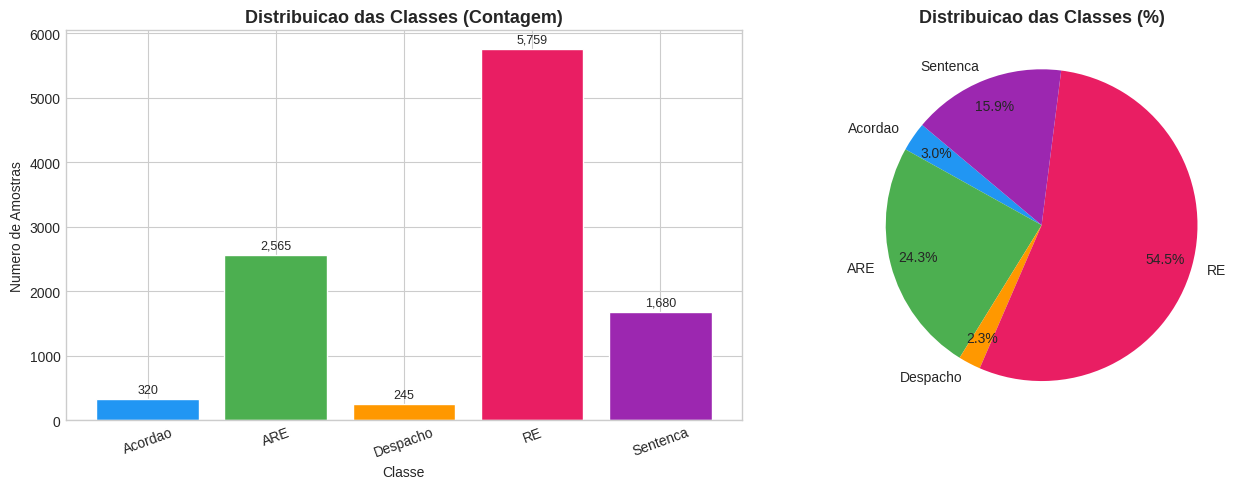

In [23]:
# Visão dos dados tratados
distribuicao_bilstm = calcular_distribuicao_classes(df_treino_tratado, incluir_rotulos_invalidos=True)
print("Distribuiçao de Classes (treino):")
display(distribuicao_bilstm)
plotar_distribuicao_classes(distribuicao_bilstm)

In [24]:
print("\n===== SEPARANDO DADOS DE TREINO EM TREINO E VALIDAÇÃO =====")
# Criamos o Treino e a Validação EXCLUSIVOS para as Redes Neurais. A função realiza uma divisão estratificada
X_tr_dl, X_vl_dl, y_tr_dl, y_vl_dl = dividir_treino_validacao(
    textos=df_treino_tratado["texto_limpo"],
    rotulos=df_treino_tratado["Category"],
    proporcao_validacao=0.2,
    random_state=42
)

print(f"Treino: {len(X_tr_dl)} | Validação: {len(X_vl_dl)} | Teste: {len(df_teste_tratado)}")
print("=============================================================")


===== SEPARANDO DADOS DE TREINO EM TREINO E VALIDAÇÃO =====
Treino: 8455 | Validação: 2114 | Teste: 2521


---

##### 3.6.1 Inicialização da Camada de Embeddings (Word2Vec Interno) e Treinamento

Para a inicialização da rede BiLSTM, evitou-se a inicialização aleatória padrão e optou-se por gerar os vetores semânticos localmente via Gensim Word2Vec, utilizando o próprio corpus do projeto.

Isso nos permite:
- Adaptação ao Domínio Jurídico
- Aproveitamento de Dados Não-Rotulados (-1)

Portanto, realizamos a indução do vocabulário e o treinamento supervisionado da rede. As principais ações foram:

1. **Reciclagem da Classe `-1`**: Utilizada estritamente para a construção do espaço semântico do Word2Vec, garantindo ganho de vocabulário sem causar *Data Leakage* no treinamento supervisionado.
2. **Dimensão do Embedding (`128`)**: Escolhida para manter um baixo custo computacional e evitar *overfitting*, dado o volume moderado de amostras do nosso *corpus*.
3. **Truncamento de Entradas (`500 tokens`)**: Definido empiricamente para capturar a argumentação central das petições, cortando ruídos procedimentais do final do texto.
4. **Iterações Treino (`15 épocas`)**: Teto de busca configurado com salvamento interno do melhor *checkpoint* (recuperação automática dos pesos com a menor perda de validação).

In [25]:
# Captura os textos -1 limpos direto da base original
print("======== Extraindo textos não-rotulados (-1) para expandir o vocabulário... ========")
textos_nao_rotulados = extrair_nao_rotulados_limpos(
    df_bruto=df_treino_bilstm_bert, 
    coluna_texto="Body", 
    coluna_alvo="Category"
)
print(f"   [OK] Capturadas {len(textos_nao_rotulados):,} linhas da classe -1.")

# Treinamento da BiLSTM com pesos penalizados para classes minoritárias
print("\n========== Treinando o BiLSTM com Word2Vec Interno... ===========")
modelo_bilstm, vocab_bilstm, hist_bilstm = treinar_bilstm_autossuficiente(
    textos_treino=X_tr_dl,
    y_treino=y_tr_dl,
    textos_val=X_vl_dl,
    y_val=y_vl_dl,
    textos_extras_w2v=textos_nao_rotulados, # Alimenta apenas o Word2Vec
    dim_embedding=128,                      # Capacidade de representação otimizada para o corpus
    comprimento_maximo=500,                 # Foco na tese jurídica principal
    batch_size=64,                          # Balanço de estabilidade de gradiente
    epocas=15                               # Margem segura para convergência da rede
)

======== Extraindo textos não-rotulados (-1) para expandir o vocabulário... ========
   [OK] Capturadas 2,268 linhas da classe -1.

========== Treinando o BiLSTM com Word2Vec Interno... ===========
  [Word2Vec Interno] Treinando semantica com 10,723 textos totais (Treino + Nao Rotulados)...
  [Word2Vec Interno] Matriz pronta: 22,956 / 22,958 palavras mapeadas.

[Motor BiLSTM] Rodando no hardware: cuda
    Epoca 01/15 | Loss Treino: 1.1053 | F1-Macro Val: 0.6211
    Epoca 02/15 | Loss Treino: 0.6088 | F1-Macro Val: 0.6735
    Epoca 03/15 | Loss Treino: 0.4641 | F1-Macro Val: 0.7029
    Epoca 04/15 | Loss Treino: 0.3957 | F1-Macro Val: 0.7600
    Epoca 05/15 | Loss Treino: 0.3400 | F1-Macro Val: 0.7483
    Epoca 06/15 | Loss Treino: 0.2761 | F1-Macro Val: 0.7896
    Epoca 07/15 | Loss Treino: 0.2416 | F1-Macro Val: 0.8021
    Epoca 08/15 | Loss Treino: 0.2096 | F1-Macro Val: 0.8209
    Epoca 09/15 | Loss Treino: 0.1707 | F1-Macro Val: 0.7966
    Epoca 10/15 | Loss Treino: 0.1756 | F1-Mac

In [26]:
# Gerar predição e CSV final.
print("iniciando Predição de Classes")

df_submissao_final_bilstm = gerar_submissao_bilstm(
    modelo=modelo_bilstm,             # Modelo final treinado no passo anterior
    vocabulario=vocab_bilstm,         # Dicionário interno
    df_teste=df_teste_tratado,
    coluna_id="Id",
    coluna_texto="texto_limpo",       
    comprimento_maximo=500,
    batch_size=64,
    nome_ficheiro_csv="submissao_bilstm_v1.csv"
)

# Exibe as primeiras 5 linhas da tabela final
display(df_submissao_final_bilstm.head())

iniciando Predição de Classes
  Prepararanda as 2,521 de teste para a BiLSTM...
  [Sucesso] 'submissao_bilstm_v1.csv' guardado com 2521 predições!


,Id,Category
0,9213,0
1,17427,1
2,4753,3
3,4640,3
4,20412,3


---

#### 3.7 Legal-BERT (Transformer)

Para a segunda abordagem profunda, realizamos o *fine-tuning* do modelo pré-treinado **Legal-BERTimbau**, um modelo pré-treinado focado no domínio jurídico em português, gerado a partir do *fine-tuning* do modelo BERTimbau.

1. **Ponto de Partida de Domínio**: Em vez do BERTimbau genérico, instanciamos um modelo já pré-treinado em acórdãos e petições do Direito brasileiro, poupando a rede de reaprender a gramática jurídica.
2. **Janela de Contexto (`512 tokens`)**: Teto arquitetural do BERT. Para evitar a perda de informação em petições longas, aplicamos uma estratégia de fatiamento no *Dataset*, capturando as extremidades do texto (onde ocorre contextualização do documento e decisão final).
3. **Otimização de Hardware (`Batch Size = 16` + `Acúmulo de Gradiente = 2`)**: Configuração montada para contornar o limite de memória da GPU. Matematicamente, a rede simula um lote real de 32 amostras por passo, estabilizando a descida do gradiente.
4. **Taxa de Aprendizado Conservadora (`2e-5`)**: Adotada para realizar ajustes finos na camada de classificação sem desconsiderar os pesos pré-treinados da atenção.
5. **Iterações no Treino (`10 épocas`)**: Teto de busca salva por um mecanismo de salvamento (*checkpointing*), que tranca na memória os exatos pesos da época que obteve a menor perda de validação.

In [27]:
print("======== INICIANDO FINE-TUNING DO LEGAL-BERTIMBAU ========")

# Fine-tuning do Transformer com simulação de lote estendido via acúmulo de gradiente
modelo_bert, tokenizer_bert, historico_bert = treinar_legal_bert_otimizado(
    textos_treino=X_tr_dl,
    y_treino=y_tr_dl,
    textos_val=X_vl_dl,
    y_val=y_vl_dl,
    max_len=512,       # Capacidade física máxima de leitura do BERT padrão
    batch_size=16,     # Teto de alocação da VRAM da placa de vídeo (via Kaggle)
    acumulo_grad=2,    # Multiplicador que gera um lote de 32 amostras (16 * 2)
    epocas=10,         # Iterações, com Checkpoint automático de menor Loss
    lr=2e-5            # Passo de aprendizado padrão para refino de arquiteturas base
)

print("\n======== GERANDO SUBMISSÃO OFICIAL DO LEGAL-BERT ========")

# Geração de Submmissão para o Kaggle
df_submissao_bert = gerar_submissao_legal_bert(
    modelo=modelo_bert,
    tokenizer=tokenizer_bert,
    df_teste=df_teste_tratado,
    coluna_id="Id",
    coluna_texto="texto_limpo",
    nome_ficheiro_csv="submissao_legal_bertimbau_final.csv"
)

# Exibe a prova do crime na tela
display(df_submissao_bert.head())

======== INICIANDO FINE-TUNING DO LEGAL-BERTIMBAU ========
  [Legal-BERT] Instanciando a arquitetura 'rufimelo/Legal-BERTimbau-base'...


config.json:   0%|          | 0.00/863 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: rufimelo/Legal-BERTimbau-base
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if yo

  [Legal-BERT] Motor alocado no hardware: cuda


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

    Época 01/10 | Loss Treino: 1.3523 | F1-Macro Val: 0.6565
    Época 02/10 | Loss Treino: 0.5898 | F1-Macro Val: 0.7353
    Época 03/10 | Loss Treino: 0.3203 | F1-Macro Val: 0.8147
    Época 04/10 | Loss Treino: 0.2089 | F1-Macro Val: 0.8514
    Época 05/10 | Loss Treino: 0.1367 | F1-Macro Val: 0.8514
    Época 06/10 | Loss Treino: 0.0933 | F1-Macro Val: 0.8238
    Época 07/10 | Loss Treino: 0.0581 | F1-Macro Val: 0.8462
    Época 08/10 | Loss Treino: 0.0391 | F1-Macro Val: 0.8512
    Época 09/10 | Loss Treino: 0.0293 | F1-Macro Val: 0.8485
    Época 10/10 | Loss Treino: 0.0212 | F1-Macro Val: 0.8452
--- FINE-TUNING JURÍDICO CONCLUÍDO | Pico de F1-Macro Val (Legal-BERT): 0.8514 ---

======== GERANDO SUBMISSÃO OFICIAL DO LEGAL-BERT ========
  [Legal-BERT Inferência] Lendo 2,521 processos inéditos de teste...
  [Sucesso] Ficheiro gerado: 'submissao_legal_bertimbau_final.csv'


,Id,Category
0,9213,0
1,17427,1
2,4753,3
3,4640,3
4,20412,3


---

#### 3.8 Ensemble (Fusão de Legal-BERT e BiLSTM)

Para a predição definitiva, combinamos as duas arquiteturas anteriores através de um **Ensemble**, onde cada modelo tem um peso na decisão final:

1. **Voto por Convicção**: Optou-se pela média ponderada das distribuições de probabilidade (`Softmax`) em detrimento do voto majoritário simples. Isto permite que a altíssima certeza de um modelo compense a hesitação decimal do outro.
2. **Busca Determinística de Pesos (*Grid Search*)**: Em vez de atribuir pesos empíricos fixos, implementou-se uma varredura linear exata na base de Validação. O peso travado para a produção é, estritamente, aquele que maximizou o F1-Macro no conjunto local.
3. **Piso de Autoridade (`50%`)**: O laço de busca do Legal-BERT inicia-se em `0.50` por premissa arquitetural: sendo o Transformer o modelo isolado de maior pontuação, impossibilitamos que o modelo BiLSTM possuísse o voto majoritário de desempate.
4. **Sincronia de Tensores**: A extração ocorre dinamicamente em memória RAM sob o parâmetro `shuffle=False`, garantindo que o vetor de convicção da petição `i` no BERT seja somado exatamente ao vetor da petição `i` na BiLSTM.

In [50]:
print("========== EXTRAINDO PROBABILIDADES DA BASE DE VALIDAÇÃO ======")

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Congela os grafos computacionais de ambos os modelos
modelo_bert.eval()
modelo_bilstm.eval()

# Extração Legal-BERT (Validação)
print("  Extraindo visão do BERT na Validação...")
ds_val_bert = DatasetBERTUnificado(X_vl_dl, rotulos=None, tokenizer=tokenizer_bert, max_len=512)
loader_val_bert = DataLoader(ds_val_bert, batch_size=32, shuffle=False)

probs_val_bert = []
with torch.no_grad(): # Desativa o motor de derivadas, poupando VRAM
    for lote in loader_val_bert:
        b_ids = lote['input_ids'].to(dispositivo)
        b_mask = lote['attention_mask'].to(dispositivo)
        
        # Otimização de processamento via FP16
        with torch.amp.autocast("cuda"):
            logits = modelo_bert(input_ids=b_ids, attention_mask=b_mask).logits
        # torch.softmax converte a saída bruta em uma escala percentual normalizada de 0.0 a 1.0
        probs_val_bert.extend(torch.softmax(logits, dim=1).cpu().numpy())

# Extração BiLSTM (Validação)
print("  Extraindo visão da BiLSTM na Validação...")
ds_val_bilstm = DatasetInferencia(X_vl_dl, vocab_bilstm, comprimento_maximo=500)
loader_val_bilstm = DataLoader(ds_val_bilstm, batch_size=64, shuffle=False)

probs_val_bilstm = []
with torch.no_grad():
    for lote_x in loader_val_bilstm:
        logits_lstm = modelo_bilstm(lote_x.to(dispositivo))
        probs_val_bilstm.extend(torch.softmax(logits_lstm, dim=1).cpu().numpy())

print("\n--- 2. CALIBRANDO A BALANÇA DO ENSEMBLE ---")

# Transformamos as listas em matrizes
matriz_val_bert = np.array(probs_val_bert)
matriz_val_lstm = np.array(probs_val_bilstm)

# Variáveis para guardar o recorde
melhor_f1_ensemble = 0.0
peso_ideal_bert = 1.0  

# Laço que testa do peso 0.50 (50%) até 1.00 (100%)
for peso_b in np.arange(0.50, 1.01, 0.01):
    peso_l = 1.0 - peso_b
    
    matriz_teste = (matriz_val_bert * peso_b) + (matriz_val_lstm * peso_l)
    preds_teste = np.argmax(matriz_teste, axis=1)
    
    # Compara a prediçõ com a classe real. Convertemos y_vl_dl para lista para não dar erro no Scikit-Learn
    f1_teste = f1_score(y_vl_dl.tolist(), preds_teste, average="macro")
    
    # Se a nota for maior, guarda o peso
    if f1_teste > melhor_f1_ensemble:
        melhor_f1_ensemble = f1_teste
        peso_ideal_bert = peso_b

print(f"  [CONCLUÍDO] Calibragem Finalizada.")
print(f"  -> Peso ideal travado para o Legal-BERT: {peso_ideal_bert * 100:.0f}%")
print(f"  -> Peso ideal travado para a BiLSTM:     {(1.0 - peso_ideal_bert) * 100:.0f}%")
print(f"  -> F1-Macro na Validação: {melhor_f1_ensemble:.4f}")

========== EXTRAINDO PROBABILIDADES DA BASE DE VALIDAÇÃO ======
  Extraindo visão do BERT na Validação...
  Extraindo visão da BiLSTM na Validação...

--- 2. CALIBRANDO A BALANÇA DO ENSEMBLE ---
  [CONCLUÍDO] Calibragem Finalizada.
  -> Peso ideal travado para o Legal-BERT: 50%
  -> Peso ideal travado para a BiLSTM:     50%
  -> F1-Macro na Validação: 0.8704


##### 3.8.1 Predição Final e Geração do Arquivo Final

Com a proporção ideal obtida na etapa anterior, realizamos a passagem dos dados de teste para a geração do CSV final de entrega no kaggle.

1. **Garantia de Integridade Posicional (`shuffle=False`)**: Parâmetro obrigatório na montagem dos fatiadores de teste. Garante que a petição de índice `i` lida pelo Legal-BERT seja somada à mesma petição `i` lida pela BiLSTM.
2. **Herança Dinâmica de Pesos**: A proporção da mescla não é declarada manualmente. Ela usa de forma autônoma a variável `peso_ideal_bert` calculada na validação, garantindo a execução contínua deste etapa.
3. **Inferência Estritamente Cega (`rotulos=None` + `.eval()`)**: O fatiador é instanciado sem as classes reais, e as redes operam com a função de derivadas desligada (`torch.no_grad()`), evitando vazamento de dados.
4. **Eficiência de Memória**: Reutilização da precisão mista para realizar a leitura de todas as petições de teste de uma só vez.

In [51]:
print("\n======== INICIANDO AJUSTE DE PREDIÇÕES  ==========")

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_bert.eval()
modelo_bilstm.eval()

# Extração no Legal-BERT (Teste)
print("  (1/3). Lendo processos da base de Teste com o Legal-BERT...")
ds_teste_bert = DatasetBERTUnificado(df_teste_tratado["texto_limpo"].tolist(), rotulos=None, tokenizer=tokenizer_bert, max_len=512)
loader_teste_bert = DataLoader(ds_teste_bert, batch_size=32, shuffle=False)

probs_teste_bert = []
with torch.no_grad():
    for lote in loader_teste_bert:
        b_ids = lote['input_ids'].to(dispositivo)
        b_mask = lote['attention_mask'].to(dispositivo)
        
        with torch.amp.autocast("cuda"):
            logits = modelo_bert(input_ids=b_ids, attention_mask=b_mask).logits
            
        probs_teste_bert.extend(torch.softmax(logits, dim=1).cpu().numpy())

# Extração na BiLSTM (Teste)
print("  (2/3). Lendo processos da base de Teste com a BiLSTM...")
ds_teste_bilstm = DatasetInferencia(df_teste_tratado["texto_limpo"].tolist(), vocab_bilstm, comprimento_maximo=500)
loader_teste_bilstm = DataLoader(ds_teste_bilstm, batch_size=64, shuffle=False)

probs_teste_bilstm = []
with torch.no_grad():
    for lote_x in loader_teste_bilstm:
        logits_lstm = modelo_bilstm(lote_x.to(dispositivo))
        probs_teste_bilstm.extend(torch.softmax(logits_lstm, dim=1).cpu().numpy())

# Fusão de pesos
print("  3/3. Aplicando pesos matemáticos gerados na Calibragem...")
# Calcula o complemento percentual da BiLSTM
peso_ideal_lstm = 1.0 - peso_ideal_bert
matriz_teste_ensemble = (np.array(probs_teste_bert) * peso_ideal_bert) + (np.array(probs_teste_bilstm) * peso_ideal_lstm)

# Captura o índice (0 a 4) da classe que somou a maior nota decimal
classes_vencedoras = np.argmax(matriz_teste_ensemble, axis=1)

# Geração do CSV
df_submissao_final = pd.DataFrame({
    "Id": df_teste_tratado["Id"],
    "Category": classes_vencedoras
})

arquivo_final = "submissao_ensemble.csv"
df_submissao_final.to_csv(arquivo_final, index=False)

print(f"\n[SUCESSO] Arquivo Final gerado: '{arquivo_final}'")
display(df_submissao_final.head())


======== INICIANDO AJUSTE DE PREDIÇÕES  ==========
  (1/3). Lendo processos da base de Teste com o Legal-BERT...
  (2/3). Lendo processos da base de Teste com a BiLSTM...
  3/3. Aplicando pesos matemáticos gerados na Calibragem...

[SUCESSO] Arquivo Final gerado: 'submissao_ensemble.csv'


,Id,Category
0,9213,0
1,17427,1
2,4753,3
3,4640,3
4,20412,3


---
## 4. Análise dos Resultados

Esta seção consolida a avaliação dos modelos clássicos e profundos treinados no projeto.

A comparação considera duas famílias de modelos:

- **Modelos clássicos**: Regressão Logística, SVM Linear e Naive Bayes com TF-IDF; além de variações com TF-IDF + NER + POS e Word2Vec.
- **Modelos profundos**: BiLSTM com embeddings Word2Vec internos, Legal-BERT e o Ensemble ponderado entre Legal-BERT e BiLSTM.

Como os modelos clássicos e profundos foram treinados em pipelines diferentes, a tabela mantém a coluna de **protocolo de validação**. Assim, a leitura principal é: comparar modelos dentro do mesmo protocolo e, em seguida, observar a tendência geral de desempenho entre abordagens.

In [52]:
# 4.1 Consolidacao de predicoes e metricas (classicos + profundos)
from torch.utils.data import DataLoader

resultados_modelos = []
mapa_preds = {}
mapa_y_true = {}

protocolo_classico = "Holdout classico (80/20 estratificado)"
protocolo_profundo = "Holdout profundo (80/20 estratificado)"

# ---------- Modelos classicos ----------
modelos_classicos_validacao = {
    "Regressao Logistica (TF-IDF)": (modelo_lr, X_validacao_tfidf),
    "SVM Linear (TF-IDF)": (modelo_svm, X_validacao_tfidf),
    "Naive Bayes (TF-IDF)": (modelo_nb, X_validacao_nn),
    "LR + Word2Vec": (modelo_lr_w2v, X_validacao_emb),
}
if "modelo_lr_ner" in globals() and modelo_lr_ner is not None:
    modelos_classicos_validacao["Regressao Logistica (TF-IDF + NER + POS)"] = (
        modelo_lr_ner,
        X_validacao_tfidf_ner,
    )
if "modelo_svm_ner" in globals() and modelo_svm_ner is not None:
    modelos_classicos_validacao["SVM Linear (TF-IDF + NER + POS)"] = (
        modelo_svm_ner,
        X_validacao_tfidf_ner,
    )

for nome_modelo, (modelo_ref, X_val) in modelos_classicos_validacao.items():
    preds = modelo_ref.predict(X_val)
    registrar_resultado_modelo(
        lista_resultados=resultados_modelos,
        mapa_predicoes=mapa_preds,
        mapa_y_verdadeiro=mapa_y_true,
        nome_modelo=nome_modelo,
        y_verdadeiro=y_vl,
        y_predito=preds,
        familia="Classico",
        protocolo_validacao=protocolo_classico,
    )

# ---------- Modelos profundos ----------
if all(nome in globals() for nome in ["modelo_bilstm", "vocab_bilstm", "X_vl_dl", "y_vl_dl"]):
    probs_bilstm_val = obter_probabilidades_bilstm(
        modelo=modelo_bilstm,
        textos=X_vl_dl,
        vocabulario=vocab_bilstm,
        dataset_inferencia_cls=DatasetInferencia,
        dataloader_cls=DataLoader,
        comprimento_maximo=500,
        batch_size=64,
    )
    preds_bilstm_val = predizer_por_probabilidades(probs_bilstm_val)

    registrar_resultado_modelo(
        lista_resultados=resultados_modelos,
        mapa_predicoes=mapa_preds,
        mapa_y_verdadeiro=mapa_y_true,
        nome_modelo="BiLSTM + Atencao",
        y_verdadeiro=np.asarray(y_vl_dl),
        y_predito=preds_bilstm_val,
        familia="Profundo",
        protocolo_validacao=protocolo_profundo,
    )

if all(nome in globals() for nome in ["modelo_bert", "tokenizer_bert", "X_vl_dl", "y_vl_dl"]):
    probs_bert_val = obter_probabilidades_legal_bert(
        modelo=modelo_bert,
        tokenizer=tokenizer_bert,
        textos=X_vl_dl,
        dataset_bert_cls=DatasetBERTUnificado,
        dataloader_cls=DataLoader,
        max_len=512,
        batch_size=32,
    )
    preds_bert_val = predizer_por_probabilidades(probs_bert_val)

    registrar_resultado_modelo(
        lista_resultados=resultados_modelos,
        mapa_predicoes=mapa_preds,
        mapa_y_verdadeiro=mapa_y_true,
        nome_modelo="Legal-BERT",
        y_verdadeiro=np.asarray(y_vl_dl),
        y_predito=preds_bert_val,
        familia="Profundo",
        protocolo_validacao=protocolo_profundo,
    )

if all(nome in globals() for nome in ["probs_bert_val", "probs_bilstm_val", "y_vl_dl"]):
    peso_bert = float(globals().get("peso_ideal_bert", 0.50))
    probs_ensemble_val = combinar_probabilidades(
        probs_bert_val,
        probs_bilstm_val,
        peso_a=peso_bert,
    )
    preds_ensemble_val = predizer_por_probabilidades(probs_ensemble_val)

    registrar_resultado_modelo(
        lista_resultados=resultados_modelos,
        mapa_predicoes=mapa_preds,
        mapa_y_verdadeiro=mapa_y_true,
        nome_modelo=f"Ensemble (BERT {peso_bert:.2f} + BiLSTM {1.0 - peso_bert:.2f})",
        y_verdadeiro=np.asarray(y_vl_dl),
        y_predito=preds_ensemble_val,
        familia="Profundo",
        protocolo_validacao=protocolo_profundo,
    )

print(f"Modelos avaliados: {len(resultados_modelos)}")
print(f"- Classicos: {sum(r['familia'] == 'Classico' for r in resultados_modelos)}")
print(f"- Profundos: {sum(r['familia'] == 'Profundo' for r in resultados_modelos)}")

Modelos avaliados: 9
- Classicos: 6
- Profundos: 3


#### 4.2 Ranking consolidado e comparacao executiva

A tabela abaixo integra os modelos das duas familias e explicita o protocolo de validacao.

- comparar **classicos entre si** (mesmo protocolo classico);
- comparar **profundos entre si** (mesmo protocolo profundo);
- observar a tendencia geral de desempenho entre familias.


Comparacao de Modelos (ordenado por F1-Macro):
                                           familia                     protocolo_validacao  n_amostras_validacao  f1_macro  f1_weighted  accuracy  precision_macro  recall_macro
modelo                                                                                                                                                                          
Ensemble (BERT 0.50 + BiLSTM 0.50)        Profundo  Holdout profundo (80/20 estratificado)                  2114    0.8704       0.8809    0.8798           0.8601        0.8825
Legal-BERT                                Profundo  Holdout profundo (80/20 estratificado)                  2114    0.8511       0.8790    0.8789           0.8434        0.8618
BiLSTM + Atencao                          Profundo  Holdout profundo (80/20 estratificado)                  2114    0.8490       0.8505    0.8477           0.8425        0.8639
SVM Linear (TF-IDF + NER + POS)           Classico  Holdout classic

,accuracy,f1_macro,f1_weighted,f1_micro,precision_macro,recall_macro,f1_Acordao,f1_ARE,f1_Despacho,f1_RE,f1_Sentenca,familia,protocolo_validacao,n_amostras_validacao
modelo,,,,,,,,,,,,,,
Ensemble (BERT 0.50 + BiLSTM 0.50),0.879849,0.870386,0.880875,0.879849,0.860090,0.882506,0.870229,0.813653,0.836735,0.897978,0.933333,Profundo,Holdout profundo (80/20 estratificado),2114
Legal-BERT,0.878903,0.851095,0.878954,0.878903,0.843392,0.861758,0.808511,0.814961,0.812500,0.903338,0.916168,Profundo,Holdout profundo (80/20 estratificado),2114
BiLSTM + Atencao,0.847682,0.849042,0.850514,0.847682,0.842534,0.863858,0.850394,0.781065,0.836735,0.863722,0.913295,Profundo,Holdout profundo (80/20 estratificado),2114
SVM Linear (TF-IDF + NER + POS),0.863378,0.824460,0.859820,0.863378,0.872251,0.789358,0.741379,0.769730,0.804598,0.893228,0.913363,Classico,Holdout classico (80/20 estratificado),2108
SVM Linear (TF-IDF),0.861480,0.820756,0.857928,0.861480,0.871013,0.783596,0.730435,0.768069,0.804598,0.892665,0.908012,Classico,Holdout classico (80/20 estratificado),2108
Regressao Logistica (TF-IDF),0.847723,0.810591,0.846790,0.847723,0.817161,0.812848,0.723404,0.779381,0.795455,0.876736,0.877980,Classico,Holdout classico (80/20 estratificado),2108
Regressao Logistica (TF-IDF + NER + POS),0.847249,0.804187,0.846657,0.847249,0.801315,0.812612,0.705036,0.782431,0.782609,0.878284,0.872576,Classico,Holdout classico (80/20 estratificado),2108
Naive Bayes (TF-IDF),0.773245,0.740469,0.774734,0.773245,0.777648,0.730908,0.640625,0.699454,0.743590,0.805929,0.812749,Classico,Holdout classico (80/20 estratificado),2108
LR + Word2Vec,0.663188,0.574052,0.678304,0.663188,0.531418,0.714788,0.398305,0.616570,0.421622,0.722772,0.710991,Classico,Holdout classico (80/20 estratificado),2108


Melhor modelo por familia:


,familia,modelo,f1_macro,protocolo_validacao
1,Profundo,Ensemble (BERT 0.50 + BiLSTM 0.50),0.870386,Holdout profundo (80/20 estratificado)
0,Classico,SVM Linear (TF-IDF + NER + POS),0.824460,Holdout classico (80/20 estratificado)


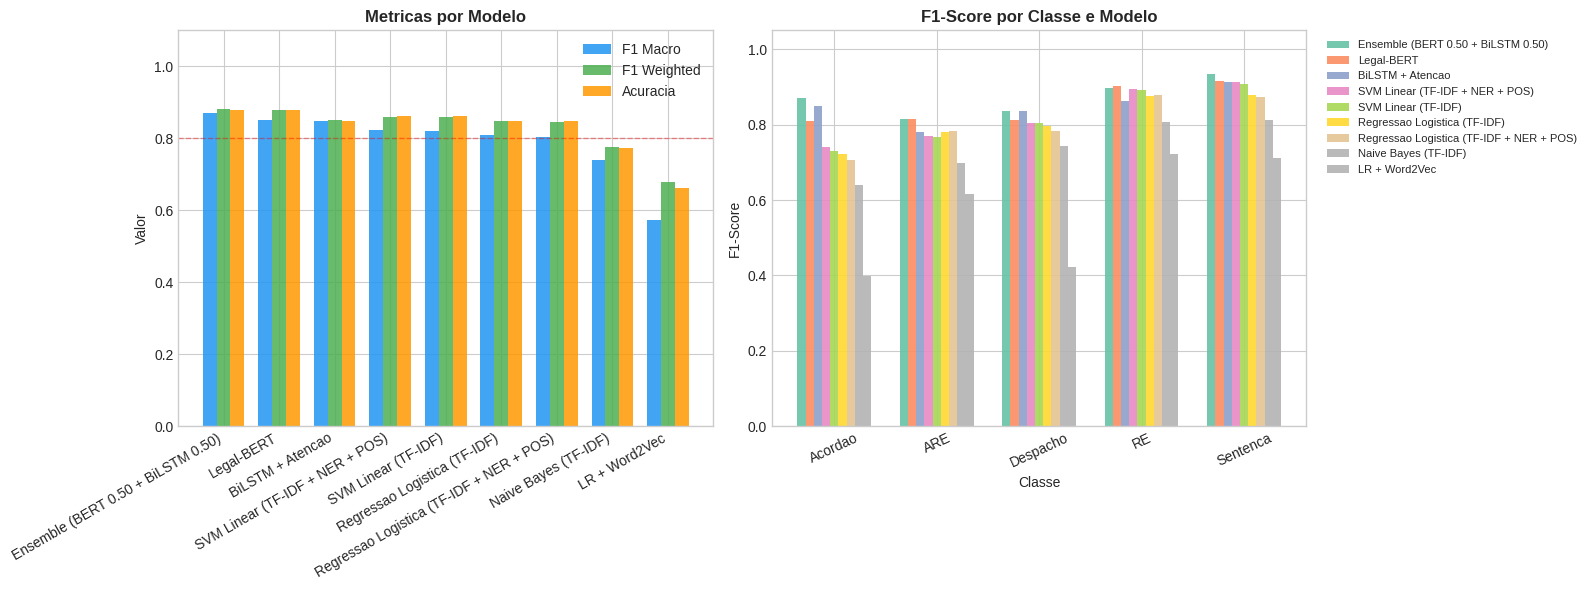

In [53]:
# Ranking geral ordenado por F1-Macro
tabela_geral = comparar_modelos(resultados_modelos)
display(tabela_geral)

# Destaque do melhor por familia
linhas_top = []
for familia in ["Classico", "Profundo"]:
    top = selecionar_top_modelos(tabela_geral, n=1, familia=familia)
    if top:
        nome = top[0]
        linhas_top.append({
            "familia": familia,
            "modelo": nome,
            "f1_macro": float(tabela_geral.loc[nome, "f1_macro"]),
            "protocolo_validacao": tabela_geral.loc[nome, "protocolo_validacao"],
        })

if linhas_top:
    print("Melhor modelo por familia:")
    display(pd.DataFrame(linhas_top).sort_values("f1_macro", ascending=False))

# Grafico comparativo (F1 global + F1 por classe)
plotar_comparacao_modelos(tabela_geral)

#### 4.3 Matrizes de confusao (melhor classico vs melhor profundo)

As matrizes abaixo mostram os erros mais relevantes de cada familia no seu respectivo protocolo de validacao.
A versao normalizada facilita a leitura de recall por classe.


--- Matriz de confusao: Ensemble (BERT 0.50 + BiLSTM 0.50) ---


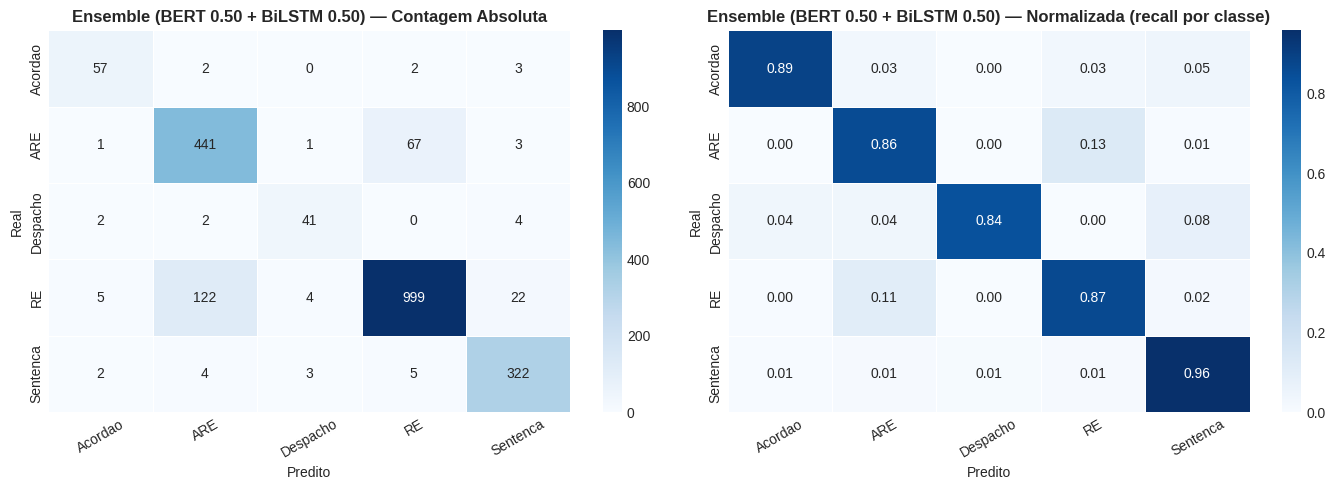


--- Matriz de confusao: Legal-BERT ---


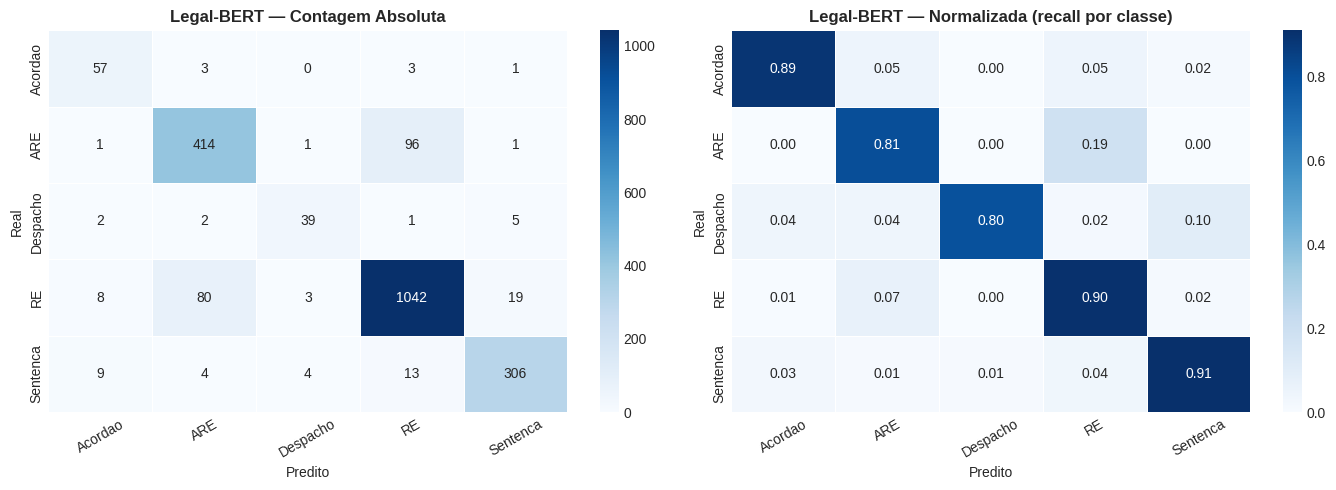

In [54]:
modelos_para_matriz = selecionar_top_modelos(tabela_geral, n=2, familia="Profundo")

for nome_modelo in modelos_para_matriz:
    print(f"\n--- Matriz de confusao: {nome_modelo} ---")
    plotar_matriz_confusao(
        y_verdadeiro=mapa_y_true[nome_modelo],
        y_predito=mapa_preds[nome_modelo],
        nome_modelo=nome_modelo,
    )

#### 4.4 Curvas de treinamento dos modelos profundos

Acompanham convergencia e estabilidade do treino para BiLSTM e Legal-BERT.
O foco e verificar se o pico de F1-Macro foi atingido com perda controlada.

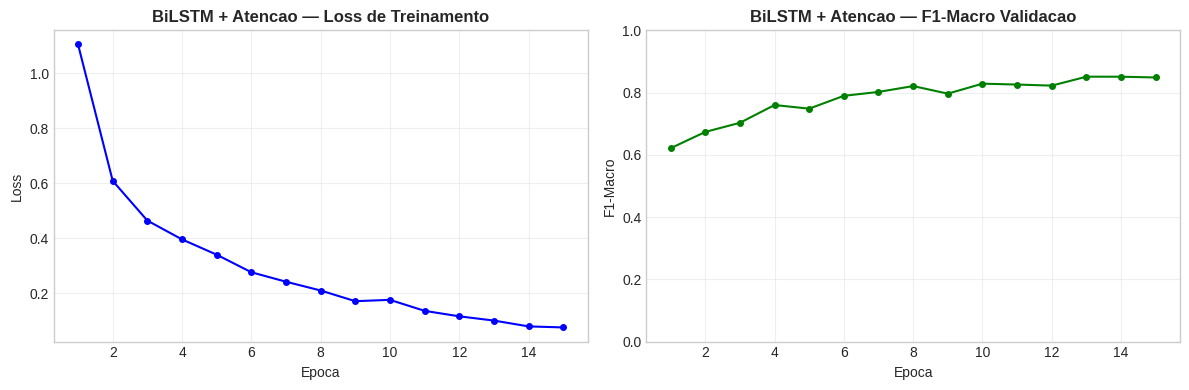

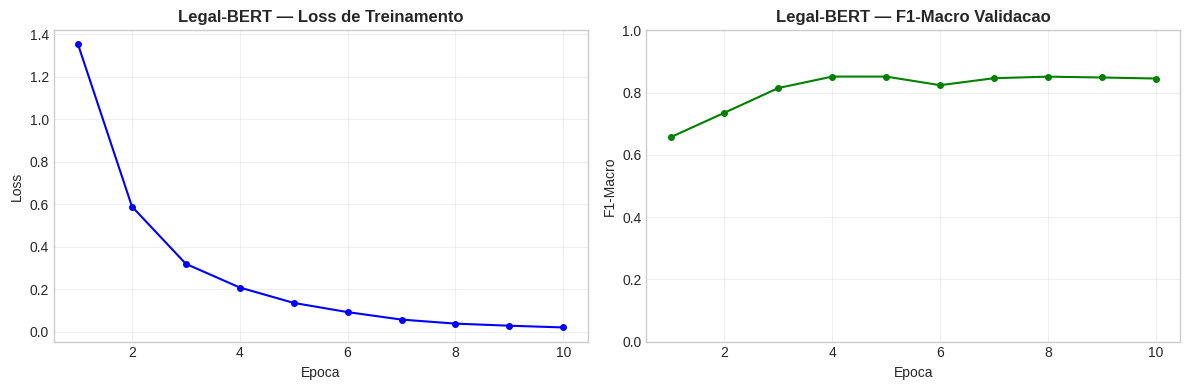

In [55]:
if "hist_bilstm" in globals():
    plotar_curvas_treinamento(hist_bilstm, nome_modelo="BiLSTM + Atencao")
else:
    print("Historico da BiLSTM nao encontrado nesta sessao.")

if "historico_bert" in globals():
    plotar_curvas_treinamento(historico_bert, nome_modelo="Legal-BERT")
else:
    print("Historico do Legal-BERT nao encontrado nesta sessao.")

#### 4.5 Teste de McNemar por familia

O teste e executado apenas entre modelos avaliados no **mesmo protocolo de validacao**.
- H0: nao ha diferenca estatisticamente significativa entre os modelos.
- p < 0.05: evidencia de diferenca significativa.

In [56]:
for familia_nome in ["Classico", "Profundo"]:
    top2 = selecionar_top_modelos(tabela_geral, n=2, familia=familia_nome)

    if len(top2) < 2:
        print(f"Familia {familia_nome}: menos de 2 modelos disponiveis para McNemar.")
        continue

    nome_a, nome_b = top2[0], top2[1]
    y_a = np.asarray(mapa_y_true[nome_a])
    y_b = np.asarray(mapa_y_true[nome_b])

    # McNemar exige a mesma base de validacao para os dois modelos
    if y_a.shape[0] != y_b.shape[0] or not np.array_equal(y_a, y_b):
        print(f"Familia {familia_nome}: modelos em bases diferentes, McNemar nao aplicado.")
        continue

    print(f"\nMcNemar ({familia_nome}): {nome_a} vs {nome_b}")
    resultado = teste_mcnemar(
        y_real=y_a,
        pred1=mapa_preds[nome_a],
        pred2=mapa_preds[nome_b],
        nome1=nome_a,
        nome2=nome_b,
    )
    print(
        f"Resumo -> chi2: {resultado.get('chi2', np.nan):.4f} | "
        f"p-valor: {resultado.get('p_valor', np.nan):.4f}"
    )


McNemar (Classico): SVM Linear (TF-IDF + NER + POS) vs SVM Linear (TF-IDF)

Teste de McNemar: SVM Linear (TF-IDF + NER + POS) vs SVM Linear (TF-IDF)
  b (SVM Linear (TF-IDF + NER + POS) certo, SVM Linear (TF-IDF) errado): 12
  c (SVM Linear (TF-IDF + NER + POS) errado, SVM Linear (TF-IDF) certo): 8
  Chi2 = 1934.8423  |  p-valor = 0.0000
  Resultado: diferenca SIGNIFICATIVA (p < 0.05). SVM Linear (TF-IDF) e superior.
Resumo -> chi2: 1934.8423 | p-valor: 0.0000

McNemar (Profundo): Ensemble (BERT 0.50 + BiLSTM 0.50) vs Legal-BERT

Teste de McNemar: Ensemble (BERT 0.50 + BiLSTM 0.50) vs Legal-BERT
  b (Ensemble (BERT 0.50 + BiLSTM 0.50) certo, Legal-BERT errado): 78
  c (Ensemble (BERT 0.50 + BiLSTM 0.50) errado, Legal-BERT certo): 76
  Chi2 = 905.2886  |  p-valor = 0.0000
  Resultado: diferenca SIGNIFICATIVA (p < 0.05). Legal-BERT e superior.
Resumo -> chi2: 905.2886 | p-valor: 0.0000


#### 4.6 Analise qualitativa de erros

Exibe amostras mal classificadas do melhor modelo classico e do melhor modelo profundo,
facilitando a leitura dos padroes de confusao por familia.

In [57]:
print("===== AUDITORIA QUALITATIVA DE ERROS (BASE DE VALIDAÇÃO) =====\n")

# Empacotamos os textos limpos da validação em uma tabela simples
df_erros_dl = pd.DataFrame({"texto_limpo": X_vl_dl})

# Extraímos a predição isolada do Legal-BERT na Validação
preds_val_bert = np.argmax(matriz_val_bert, axis=1)

print("--- ANÁLISE DE ERROS: LEGAL-BERT (ISOLADO) ---")
analisar_erros(
    df_val=df_erros_dl,
    y_real=y_vl_dl,
    y_pred=preds_val_bert,
    coluna_texto="texto_limpo",
    n=5,
)

# Recalculamos a predição exata do Ensemble na Validação usando o peso travado
peso_ideal_lstm = 1.0 - peso_ideal_bert
matriz_val_ensemble = (matriz_val_bert * peso_ideal_bert) + (matriz_val_lstm * peso_ideal_lstm)
preds_val_ensemble = np.argmax(matriz_val_ensemble, axis=1)

print("\n--- ANÁLISE DE ERROS: ENSEMBLE ---")
analisar_erros(
    df_val=df_erros_dl,
    y_real=y_vl_dl,
    y_pred=preds_val_ensemble,
    coluna_texto="texto_limpo",
    n=5,
)

===== AUDITORIA QUALITATIVA DE ERROS (BASE DE VALIDAÇÃO) =====

--- ANÁLISE DE ERROS: LEGAL-BERT (ISOLADO) ---

Analise de Erros (primeiros 5 casos):
----------------------------------------------------------------------
  Real: ARE          | Previsto: RE           | Texto: vigentes época concessão rms turma rel min sydney sanches dju turma rel min moreira alves dju assim para concessão benef...
  Real: ARE          | Previsto: RE           | Texto: página de por outro lado DECRETO_53831 seu código previu exposição eletricidade nesses termos eletricidade operações loc...
  Real: Acordao      | Previsto: RE           | Texto: constitucional indissociável direito vida poder público qualquer que seja esfera institucional sua atuação plano organiz...
  Real: RE           | Previsto: ARE          | Texto: ainda que ultrapassadas preliminares supra mérito verifica que recurso não tem mínimas condições prosperar consoante dis...
  Real: RE           | Previsto: ARE          | Texto: assessor

#### 4.7 Geracao das submissoes

Gera submissao do melhor modelo classico e registra a submissao final profunda
(ensemble), reaproveitando o que ja foi produzido na Secao 3 quando disponivel.

In [58]:
ids_teste = df_teste["Id"].values

# ---------- Submissao classica (melhor classico no ranking) ----------
modelos_classicos_teste = {
    "Regressao Logistica (TF-IDF)": (modelo_lr, X_teste_tfidf),
    "SVM Linear (TF-IDF)": (modelo_svm, X_teste_tfidf),
    "Naive Bayes (TF-IDF)": (modelo_nb, X_teste_nn),
    "LR + Word2Vec": (modelo_lr_w2v, X_teste_emb),
}
if "modelo_lr_ner" in globals() and modelo_lr_ner is not None:
    modelos_classicos_teste["Regressao Logistica (TF-IDF + NER + POS)"] = (
        modelo_lr_ner,
        X_teste_tfidf_ner,
    )
if "modelo_svm_ner" in globals() and modelo_svm_ner is not None:
    modelos_classicos_teste["SVM Linear (TF-IDF + NER + POS)"] = (
        modelo_svm_ner,
        X_teste_tfidf_ner,
    )

nomes_classicos_ordenados = [
    nome for nome in tabela_geral.index.tolist()
    if nome in modelos_classicos_teste
]

if nomes_classicos_ordenados:
    nome_classico_escolhido = nomes_classicos_ordenados[0]
else:
    nome_classico_escolhido = "SVM Linear (TF-IDF)"

modelo_classico_teste, X_teste_classico = modelos_classicos_teste[nome_classico_escolhido]
preds_classico_teste = modelo_classico_teste.predict(X_teste_classico)

df_submissao_classica = gerar_submissao(
    ids=ids_teste,
    predicoes=preds_classico_teste,
    nome_arquivo="submission_classico.csv",
)
print(f"Submissao classica gerada com: {nome_classico_escolhido}")
display(df_submissao_classica.head())

print("Distribuicao das classes preditas (classico):")
display(pd.Series(preds_classico_teste).value_counts().rename(index=MAPEAMENTO_CLASSES).rename("contagem"))

# ---------- Submissao profunda final (ensemble) ----------
if "df_submissao_final" in globals():
    print("Submissao profunda ja gerada anteriormente: submissao_ensemble.csv")
    display(df_submissao_final.head())
else:
    if all(nome in globals() for nome in ["modelo_bert", "tokenizer_bert", "modelo_bilstm", "vocab_bilstm", "df_teste_tratado"]):
        from torch.utils.data import DataLoader

        probs_bert_teste = obter_probabilidades_legal_bert(
            modelo=modelo_bert,
            tokenizer=tokenizer_bert,
            textos=df_teste_tratado["texto_limpo"].tolist(),
            dataset_bert_cls=DatasetBERTUnificado,
            dataloader_cls=DataLoader,
            max_len=512,
            batch_size=32,
        )
        probs_bilstm_teste = obter_probabilidades_bilstm(
            modelo=modelo_bilstm,
            textos=df_teste_tratado["texto_limpo"].tolist(),
            vocabulario=vocab_bilstm,
            dataset_inferencia_cls=DatasetInferencia,
            dataloader_cls=DataLoader,
            comprimento_maximo=500,
            batch_size=64,
        )

        peso_bert = float(globals().get("peso_ideal_bert", 0.50))
        probs_ensemble_teste = combinar_probabilidades(
            probs_bert_teste,
            probs_bilstm_teste,
            peso_a=peso_bert,
        )
        preds_ensemble_teste = predizer_por_probabilidades(probs_ensemble_teste)

        df_submissao_final = gerar_submissao(
            ids=ids_teste,
            predicoes=preds_ensemble_teste,
            nome_arquivo="submissao_ensemble.csv",
        )
        print("Submissao profunda (ensemble) gerada nesta secao.")
        display(df_submissao_final.head())
    else:
        print("Modelos profundos indisponiveis para gerar submissao nesta sessao.")

Submissao salva em 'submission_classico.csv' com 2,521 linhas.
Submissao classica gerada com: SVM Linear (TF-IDF + NER + POS)


,Id,Category
0,9213,0
1,17427,3
2,4753,3
3,4640,3
4,20412,3


Distribuicao das classes preditas (classico):


RE          1685
ARE          362
Sentenca     346
Acordao       76
Despacho      52
Name: contagem, dtype: int64

Submissao profunda ja gerada anteriormente: submissao_ensemble.csv


,Id,Category
0,9213,0
1,17427,1
2,4753,3
3,4640,3
4,20412,3
